# LIBRARIES

In [1]:
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels
# !pip install statsforecast
# !pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal
from pandas.plotting import lag_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive, RandomWalkWithDrift
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Loading, converting and cleaning of the data

## MARKET TEMPERATURE DATASET LOAD

The "Market temperature index" dataset is loaded by using pandas library from python. 

In [3]:
df_market_temp = pd.read_csv("dataset/Market_temp_index_uc_month.csv")

In [4]:
df_market_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0
1,394913,1,"New York, NY",msa,NY,53.0,52.0,55.0,57.0,56.0,...,92.0,90.0,87.0,81.0,78.0,77.0,77.0,74.0,71.0,71.0
2,753899,2,"Los Angeles, CA",msa,CA,69.0,66.0,66.0,67.0,66.0,...,85.0,83.0,80.0,74.0,71.0,67.0,65.0,63.0,62.0,63.0
3,394463,3,"Chicago, IL",msa,IL,48.0,49.0,51.0,52.0,51.0,...,74.0,76.0,75.0,71.0,67.0,64.0,61.0,58.0,56.0,56.0
4,394514,4,"Dallas, TX",msa,TX,55.0,55.0,58.0,60.0,59.0,...,67.0,67.0,64.0,59.0,55.0,52.0,49.0,48.0,49.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,753929,935,"Zapata, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,39.0,36.0,27.0,40.0,53.0,47.0,31.0,34.0,42.0,41.0
924,394743,936,"Ketchikan, AK",msa,AK,37.0,35.0,34.0,37.0,49.0,...,74.0,69.0,49.0,53.0,61.0,66.0,57.0,53.0,44.0,50.0
925,753874,937,"Craig, CO",msa,CO,3.0,23.0,52.0,67.0,56.0,...,61.0,55.0,59.0,57.0,48.0,33.0,21.0,28.0,41.0,37.0
926,395188,938,"Vernon, TX",msa,TX,51.0,45.0,NaN,48.0,65.0,...,83.0,78.0,64.0,65.0,61.0,52.0,57.0,56.0,51.0,43.0


In [5]:
df_market_temp['RegionID'].count()


np.int64(928)

## Reshaping the market temprature dataset

We can see that market temperature dataset has 928 rows and 88 columns. First 5 columns are:

- ***RegionID:*** Unique identifier. Each US region has an id. 102001 is United States id, not a specific country. 
There 928 different IDs, except 102001, all other corrispond to a specific region. 
- ***SizeRank:*** Ranking of the region from most populated to the less populated. SizeRank has 925 different values. 
It means that some of countries have the same rank. They are not NaN values (except United States obviously), 
I won't "fix" it since it is not a specific region.
- ***RegionName:*** Associates a name to id number. 928 different Region names obviously. 
- ***RegionType:*** 2 different types of regions:
    - **country:** Since we have a row about the United States, here the country is only for US. 
    - **msa:** Metropolitan Statistical Area (all 927 remaining rows).
- ***StateName:*** The name of each state (US of course is NaN)


**Date columns:**<br>
As we can see the other 83 remaining columnns are dates. Pandas sees those dates as a column name (string) not a date sequence. 
So, I need to transform them to do time series analysis. 
I used pandas.melt() function to reshape them from wide to long format, turning every date column into two proper columns: 
a date and its corresponding value. This produces one row per region-month observation, indexable as a genuine time series.

In [6]:
df_market_temp.shape

(928, 88)

In [7]:
df_market_temp_updated = df_market_temp.copy()

# pivoting all date columns into rows
df_market_temp_updated = pd.melt(
    df_market_temp,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'], # keep the columns as they are
    var_name='Date',           # the new column that holds dates that were columns
    value_name='MarketTemperature'  # the new column that holds the temperature values, now we have 88 rows for each date and we can see the temperature 
                                    # values here  not like first version that for each region there were 88 columns that holds these temperatures. 
)

# convert columns into pandas timestamp 
df_market_temp_updated['Date'] = pd.to_datetime(df_market_temp_updated['Date'])

# make Date the row index, not just a regular column
df_market_temp_updated.set_index('Date', inplace=True)

In [8]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,NaN,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


In [9]:
df_market_temp_updated.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'MarketTemperature'],
      dtype='object')

In [10]:
df_market_temp_updated.index

DatetimeIndex(['2018-01-31', '2018-01-31', '2018-01-31', '2018-01-31',
               '2018-01-31', '2018-01-31', '2018-01-31', '2018-01-31',
               '2018-01-31', '2018-01-31',
               ...
               '2024-11-30', '2024-11-30', '2024-11-30', '2024-11-30',
               '2024-11-30', '2024-11-30', '2024-11-30', '2024-11-30',
               '2024-11-30', '2024-11-30'],
              dtype='datetime64[ns]', name='Date', length=77024, freq=None)

In [11]:
len(df_market_temp_updated.index.unique())

83

## Market temprature data cleaning:
missing values: 
- in *StateName* there are 83 missing values, but we can see that the United State has a row by its own but don't have anything in StateName,<br> 
after checking I saw that there is no any region with state name "US" or "us" so instead of deleting United States from the table I will just add "US" as its StateName. 

- There are other missing values in the *MarketTemperature* column. I will use ***forward fill - ffill*** method to fill them.<br> 
Since pandas scan each column from top to bottom (earliest date to latest date) the index moves in chronological order and when it hits a NaN value,<br> 
ffill method looks backwards and copies the last known real value. The problem with this method can be the very first value is NaN,<br> 
in that case I can use ***bfill*** method, which propagates the next known valid value backward to replace missing values.

In [12]:
df_market_temp_updated.isnull().sum()

RegionID                0
SizeRank                0
RegionName              0
RegionType              0
StateName              83
MarketTemperature    2220
dtype: int64

In [13]:
df_market_temp_updated['RegionType'].unique()

array(['country', 'msa'], dtype=object)

In [14]:
df_market_temp_updated[(df_market_temp_updated['RegionType'] == 'country') & (df_market_temp_updated['RegionName'] == 'United States')]


,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,NaN,50.0
2018-02-28,102001,0,United States,country,NaN,50.0
2018-03-31,102001,0,United States,country,NaN,52.0
2018-04-30,102001,0,United States,country,NaN,54.0
2018-05-31,102001,0,United States,country,NaN,55.0
...,...,...,...,...,...,...
2024-07-31,102001,0,United States,country,NaN,55.0
2024-08-31,102001,0,United States,country,NaN,53.0
2024-09-30,102001,0,United States,country,NaN,52.0


In [15]:
df_market_temp_updated[df_market_temp_updated['StateName']=="US"]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,


In [16]:
df_market_temp_updated[df_market_temp_updated['StateName']=="us"]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,


In [17]:
df_market_temp_updated['StateName'] = df_market_temp_updated['StateName'].fillna('US')

In [18]:
df_market_temp_updated.isnull().sum()

RegionID                0
SizeRank                0
RegionName              0
RegionType              0
StateName               0
MarketTemperature    2220
dtype: int64

Market temperature missing values fix

In [19]:
# sort first so ffill travels in chronological order
df_market_temp_updated = df_market_temp_updated.sort_index()

df_market_temp_updated['MarketTemperature'] = (
    df_market_temp_updated.groupby('StateName')['MarketTemperature'] # Grouping is important to avoid that first NaN value of a state uses the last value of previous state.
    .ffill()   # fill gaps using last known value within same state
    .bfill()   # catch any NaNs at the very start of a state's history
)

print(df_market_temp_updated['MarketTemperature'].isna().sum())  

0


In [20]:
df_market_temp_updated.isnull().sum()

RegionID             0
SizeRank             0
RegionName           0
RegionType           0
StateName            0
MarketTemperature    0
dtype: int64

In [21]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,US,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


In [22]:
len(df_market_temp_updated['StateName'].unique())

51

## MEDIAN SALE PRICE

In [23]:
df_sale_price = pd.read_csv("dataset/Median_sale_price_uc_month.csv")

In [24]:
df_sale_price

,RegionID,SizeRank,RegionName,RegionType,StateName,2008-02-29,2008-03-31,2008-04-30,2008-05-31,2008-06-30,...,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31
0,102001,0,United States,country,NaN,170922.0,175612.0,177500.0,180000.0,185000.0,...,324000.0,335000.0,345000.0,350000.0,360000.0,369000.0,361000.0,360000.0,350500.0,355000.0
1,394913,1,"New York, NY",msa,NY,397000.0,390000.0,390000.0,390000.0,399900.0,...,570000.0,565000.0,575000.0,585000.0,615000.0,640000.0,649450.0,640000.0,625000.0,624451.0
2,753899,2,"Los Angeles, CA",msa,CA,470000.0,455000.0,457000.0,440000.0,435000.0,...,865000.0,915000.0,916250.0,950000.0,970000.0,960000.0,950500.0,932000.0,915000.0,941000.0
3,394463,3,"Chicago, IL",msa,IL,216750.0,220000.0,221000.0,227000.0,235000.0,...,279000.0,285000.0,300000.0,315000.0,325000.0,337275.0,330000.0,320000.0,317881.0,315000.0
4,394514,4,"Dallas, TX",msa,TX,138000.0,146000.0,144950.0,150000.0,156000.0,...,368000.0,380000.0,390000.0,400000.0,405000.0,400000.0,395000.0,390000.0,380000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,394869,869,"Moberly, MO",msa,MO,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,139000.0,152000.0,163250.0,180500.0,186000.0,46338.0,185900.0
709,394371,891,"Beatrice, NE",msa,NE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200000.0
710,753914,908,"Port Lavaca, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,177884.0,209255.0,103075.0,140948.0
711,395003,912,"Price, UT",msa,UT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,228500.0,305000.0


In [25]:
df_sale_price.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2008-02-29', '2008-03-31', '2008-04-30', '2008-05-31', '2008-06-30',
       ...
       '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30', '2024-05-31',
       '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30', '2024-10-31'],
      dtype='object', length=206)

### Reshaping the Median Sale Price dataset

Same problem as previous, dates are columns also here. So I will apply the same .melt() method to make those date indexes. 

In [26]:
df_sale_price_updated = df_sale_price.copy()

df_sale_price_updated = pd.melt(
    df_sale_price,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'], 
    var_name='Date',          
    value_name='MedianSalePrice'  
)

df_sale_price_updated['Date'] = pd.to_datetime(df_sale_price_updated['Date'])

df_sale_price_updated.set_index('Date', inplace=True)

In [27]:
df_sale_price_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,NaN,170922.0
2008-02-29,394913,1,"New York, NY",msa,NY,397000.0
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,394463,3,"Chicago, IL",msa,IL,216750.0
2008-02-29,394514,4,"Dallas, TX",msa,TX,138000.0
...,...,...,...,...,...,...
2024-10-31,394869,869,"Moberly, MO",msa,MO,185900.0
2024-10-31,394371,891,"Beatrice, NE",msa,NE,200000.0
2024-10-31,753914,908,"Port Lavaca, TX",msa,TX,140948.0


### Median sale price Datasets cleaning: 

missing values: 
- StateName: same as market temperature dataset. I am going to fill missing StateName for United States with "US"
- MedianSalePrice: by calculating 27447 missing values over total 143313, we can see that almost 20% of total data are missing, this gap is huge. To handle this missing values I am going to use the same methods. ***ffill*** and ***bfill*** as before. 

In [28]:
df_sale_price_updated.isnull().sum()

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName            201
MedianSalePrice    27447
dtype: int64

In [29]:
df_sale_price_updated['StateName'] = df_sale_price_updated['StateName'].fillna('US')

#### !!!Individuate the cities with more data richness (provide more info) -> I'll need it to proof the cities selection at point 3

I do this in this point because i want to check the data richness before filling missing values. 

In [30]:
data_richness = (
    df_sale_price_updated[df_sale_price_updated['StateName'] != 'US']
    .groupby('StateName')
    .agg(
        TotalValues=('MedianSalePrice', 'size'),
        TotalMissingValues=('MedianSalePrice', lambda x: x.isna().sum())
    )
    .reset_index()
)

data_richness['ValuesAfterDropMissing'] = (
    data_richness['TotalValues']
    - data_richness['TotalMissingValues']
)

data_richness = data_richness.sort_values(
    by='ValuesAfterDropMissing',
    ascending=False
)

data_richness = data_richness.sort_values('ValuesAfterDropMissing', ascending=False)
data_richness.head(10)
# data_richness[data_richness['StateName']=='']

,StateName,TotalValues,TotalMissingValues,ValuesAfterDropMissing
25,NC,6834,788,6046
3,CA,6030,0,6030
33,OH,8442,2578,5864
41,TX,6834,1513,5321
7,FL,5427,283,5144
36,PA,6231,1354,4877
20,MI,6231,1356,4875
8,GA,4623,147,4476
40,TN,4623,300,4323
46,WI,4422,372,4050


The 5 states are selected based on different criteria: 
- Data quality: states with less missing values
- Geographic diversity: different regions  of US
- Market size diversity: some of selected states have large markets and some small markets

In [31]:
selected_states = {
    'NC': 'North Carolina',
    'CA': 'California',
    'WA': 'Washington',
    'TX': 'Texas',
    'PA': 'Pennsylvania'
}

### Fix missing values

I fill the missing values with the same criteria I used in the market tempreature index dataset: ffill() and bfill(). 

In [32]:
df_sale_price_updated.isna().sum()

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName              0
MedianSalePrice    27447
dtype: int64

In [33]:
df_sale_price_updated = df_sale_price_updated.sort_index()

df_sale_price_updated['MedianSalePrice'] = (
    df_sale_price_updated.groupby('StateName')['MedianSalePrice']
    .ffill()
    .bfill()
)

print(df_sale_price_updated['MedianSalePrice'].isna().sum())  


0


In [34]:
df_sale_price_updated.isnull().sum()

RegionID           0
SizeRank           0
RegionName         0
RegionType         0
StateName          0
MedianSalePrice    0
dtype: int64

## TRAIN/TEST SPLIT

to use in future

In [35]:
# Market heat index
market_temp_train = df_market_temp_updated[df_market_temp_updated.index < '2022-01-01']
market_temp_test  = df_market_temp_updated[df_market_temp_updated.index >= '2022-01-01']

# Median sale price
median_sale_train = df_sale_price_updated[df_sale_price_updated.index < '2022-01-01']
median_sale_test  = df_sale_price_updated[df_sale_price_updated.index >= '2022-01-01']


# 2. Exploring the dataset with descriptive statistics and frequency analysis. Use appropriate graphs

## Descriptive Statistics for Market Temperature Index 

As we can see from .describe() the market temperature ranges from -102 to 238, not between 0-100 as usually happens, the index is unbounded. With a ***mean*** of ~53 still indicates markets are mildly seller-favoring on average. <br>
We can also see that the standard deviation is ~22, quite high, relative to the mean, meaning there's a lot of variation across regions and time, some markets are very cold, others very hot

---
To better understand the distribution of extreme values, I decided to examine the hottest, coldest, and most negative markets by average and minimum temperature.

The hottest markets on average are Rochester NY (116.7) and San Francisco CA (104.9), both highly competitive housing markets<br> 
with strong demand and limited supply,confirming that values well above 100 reflect real market conditions rather than data errors.

The coldest markets on average are smaller, less prominent cities: Oil City PA (15.7), Sault Ste. Marie MI (25.7), and Sunbury PA (25.9).<br> 
These are low-demand areas where buyers consistently have more negotiating power.

The most extreme single negative values are recorded in Rockingham NC (-102), Bennettsville SC (-88), and Sunbury PA (-87), all small,<br> 
economically weaker metros where at certain points in time supply far exceeded demand, pushing the index deeply negative. <br>
At some point those regions hit the peak of the most buyer-favoring prices. 

This confirms that the index is unbounded by design: extreme positive values cluster in large, competitive coastal and northeastern cities,<br> 
while extreme negative values appear in small, economically marginal markets.

In [36]:
df_market_temp_updated.describe()

,RegionID,SizeRank,MarketTemperature
count,77024.000000,77024.000000,77024.000000
mean,425513.622845,469.393319,53.332130
std,105754.096874,270.988723,22.743761
min,102001.000000,0.000000,-102.000000
25%,394555.750000,234.750000,41.000000
50%,394812.500000,470.500000,52.000000
75%,395073.500000,703.250000,66.000000
max,845172.000000,939.000000,238.000000


In [37]:
# Markets with highest average temperature: most seller-favoring
top_hot = (df_market_temp_updated.groupby('RegionName')['MarketTemperature']
           .mean()
           .sort_values(ascending=False)
           .head(5))

# Markets with lowest average temperature: most buyer-favoring or negative
top_cold = (df_market_temp_updated.groupby('RegionName')['MarketTemperature']
            .mean()
            .sort_values(ascending=True)
            .head(5))

# Markets that recorded the most extreme negative values
most_negative = (df_market_temp_updated.groupby('RegionName')['MarketTemperature']
                 .min()
                 .sort_values(ascending=True)
                 .head(5))

print("Top 5 hottest markets (highest average temperature):")
print(top_hot.to_string())
print("\nTop 5 coldest markets (lowest average temperature):")
print(top_cold.to_string())
print("\nMarkets with most extreme single negative values:")
print(most_negative.to_string())

Top 5 hottest markets (highest average temperature):
RegionName
Rochester, NY        116.686747
San Francisco, CA    104.939759
Buffalo, NY           99.674699
San Jose, CA          95.843373
Kennewick, WA         86.855422

Top 5 coldest markets (lowest average temperature):
RegionName
Oil City, PA            15.698795
Sault Ste. Marie, MI    25.674699
Sunbury, PA             25.867470
Elkins, WV              26.445783
Danville, IL            26.903614

Markets with most extreme single negative values:
RegionName
Rockingham, NC      -102.0
Bennettsville, SC    -88.0
Sunbury, PA          -87.0
Oil City, PA         -79.0
Decatur, IN          -76.0


In [38]:
df_market_temp_updated[df_market_temp_updated['MarketTemperature'] < 0]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,394597,228,"Florence, SC",msa,SC,-12.0
2018-01-31,395151,235,"Terre Haute, IN",msa,IN,-5.0
2018-01-31,394917,282,"Niles, MI",msa,MI,-15.0
2018-01-31,394723,291,"Jefferson City, MO",msa,MO,-8.0
2018-01-31,394537,293,"Dothan, AL",msa,AL,-1.0
...,...,...,...,...,...,...
2024-11-30,394915,756,"Newport, TN",msa,TN,-3.0
2024-11-30,394525,757,"Decatur, IN",msa,IN,-5.0
2024-11-30,394331,774,"Angola, IN",msa,IN,-5.0


In [39]:
df_market_temp_updated[df_market_temp_updated['MarketTemperature'] > 100]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,395057,12,"San Francisco, CA",msa,CA,123.0
2018-01-31,395059,36,"San Jose, CA",msa,CA,141.0
2018-02-28,395057,12,"San Francisco, CA",msa,CA,103.0
2018-02-28,395059,36,"San Jose, CA",msa,CA,113.0
2018-04-30,395224,94,"Wichita, KS",msa,KS,206.0
...,...,...,...,...,...,...
2024-08-31,394526,716,"Defiance, OH",msa,OH,105.0
2024-08-31,395084,784,"Seneca Falls, NY",msa,NY,114.0
2024-09-30,395031,52,"Rochester, NY",msa,NY,134.0


### Distribution of Market Temperature Index 

- Distribution is roughly bell-shaped but right-skewed, see that the right tail stretches toward 200+
- Most market temperatures fall between 20 and 80
- Mean (53.3) and median (52.0) are very close, confirming only mild skew
- We can see also that negative values are a small minority, which means most markets are seller-favoring

In [40]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,US,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


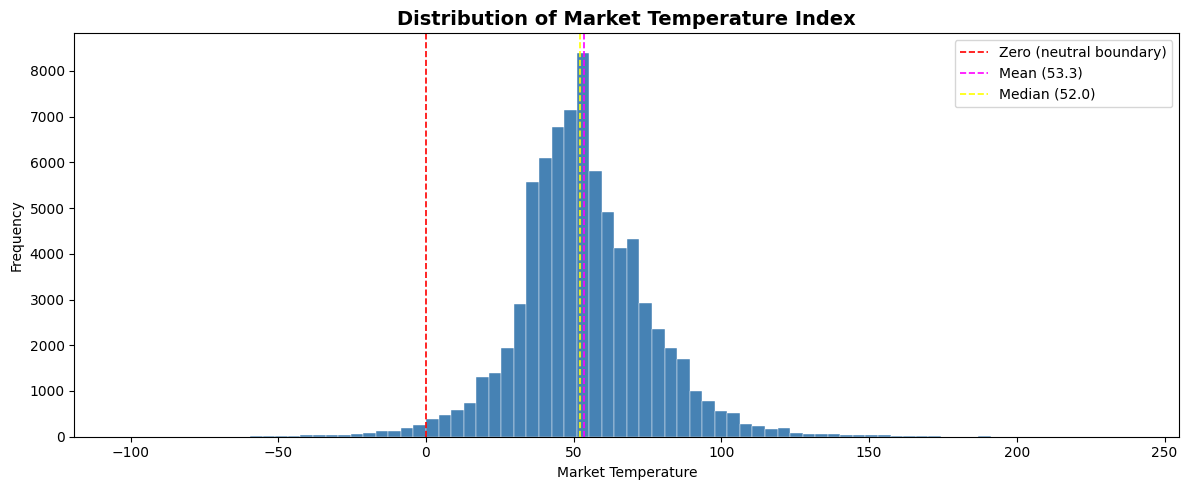

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_market_temp_updated['MarketTemperature'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero (neutral boundary)')
ax.axvline(df_market_temp_updated['MarketTemperature'].mean(), color='magenta', linestyle='--', linewidth=1.2, label=f"Mean ({df_market_temp_updated['MarketTemperature'].mean():.1f})")
ax.axvline(df_market_temp_updated['MarketTemperature'].median(), color='yellow', linestyle='--', linewidth=1.2, label=f"Median ({df_market_temp_updated['MarketTemperature'].median():.1f})")

ax.set_title('Distribution of Market Temperature Index', fontsize=14, weight='bold')
ax.set_xlabel('Market Temperature')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## Descriptive Statistics for Median Sale Price

The median sale price ranges from $24,500 to $1,767,500: this is a huge gap in US housing markets.  Indicating an enormous spread reflecting the diversity of US housing markets. 

The mean ($185,565) is notably higher than the median(50%) ($151,928), this confirm the right-skewed distribution we can see also in the histogram. 

The standard deviation of $120,455 is about 65% of the mean which is very high considering that in many natural phenomena, a "low" std is roughly 10–20% of the mean. It indicate that price levels vary dramatically across regions.

In [42]:
df_sale_price_updated.describe()

,RegionID,SizeRank,MedianSalePrice
count,143313.000000,143313.000000,1.433130e+05
mean,415663.527349,381.661992,1.855648e+05
std,88602.896386,234.345697,1.204553e+05
min,102001.000000,0.000000,2.450000e+04
25%,394539.000000,181.000000,1.150000e+05
50%,394795.000000,367.000000,1.519280e+05
75%,395046.000000,570.000000,2.150000e+05
max,845172.000000,916.000000,1.767500e+06


### Distribution of Median Sale Price Index

Strongly right-skewed distribution: most prices cluster below $250k, but a long tail extends to $1.75M+

Mean ($185k) is significantly higher than median ($152k): this means that most markets are actually cheaper than the mean suggests, but a minority of very expensive markets (like big citites' markets) are pulling the average up.

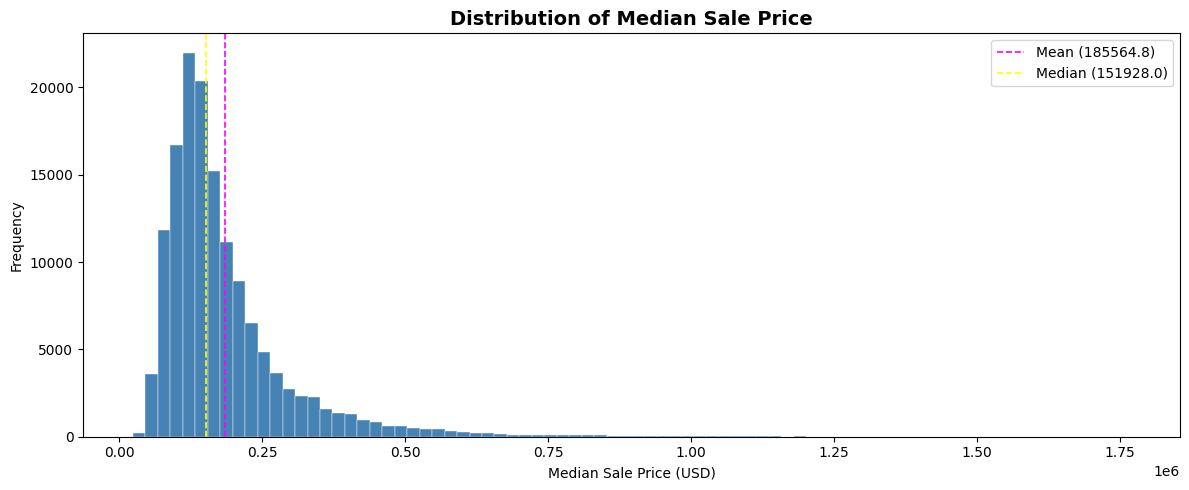

In [43]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_sale_price_updated['MedianSalePrice'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)


ax.axvline(df_sale_price_updated['MedianSalePrice'].mean(), color='magenta', linestyle='--', linewidth=1.2, label=f"Mean ({df_sale_price_updated['MedianSalePrice'].mean():.1f})")
ax.axvline(df_sale_price_updated['MedianSalePrice'].median(), color='yellow', linestyle='--', linewidth=1.2, label=f"Median ({df_sale_price_updated['MedianSalePrice'].median():.1f})")

ax.set_title('Distribution of Median Sale Price', fontsize=14, weight='bold')
ax.set_xlabel('Median Sale Price (USD)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## US ANALYSIS ONLY

In [44]:
us_temp = df_market_temp_updated[
    (df_market_temp_updated['RegionName'] == 'United States') & 
    (df_market_temp_updated['RegionType'] == 'country')
]

In [45]:
us_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,US,50.0
2018-02-28,102001,0,United States,country,US,50.0
2018-03-31,102001,0,United States,country,US,52.0
2018-04-30,102001,0,United States,country,US,54.0
2018-05-31,102001,0,United States,country,US,55.0
...,...,...,...,...,...,...
2024-07-31,102001,0,United States,country,US,55.0
2024-08-31,102001,0,United States,country,US,53.0
2024-09-30,102001,0,United States,country,US,52.0


The market temperature index started around ~50 in 2018, but after 2020 it started to rise rapidly most likely because of COVID19 and hit the peak  in early 2022 <br> 
-> we know that a higher temperature means that the market is more favourable for sellers.  <br>
From there the temperature fell rapidly, and by late 2024 it was back to ~50. The post-2022 cooldown lines up perfectly with rising interest rates pricing many buyers out of the market.

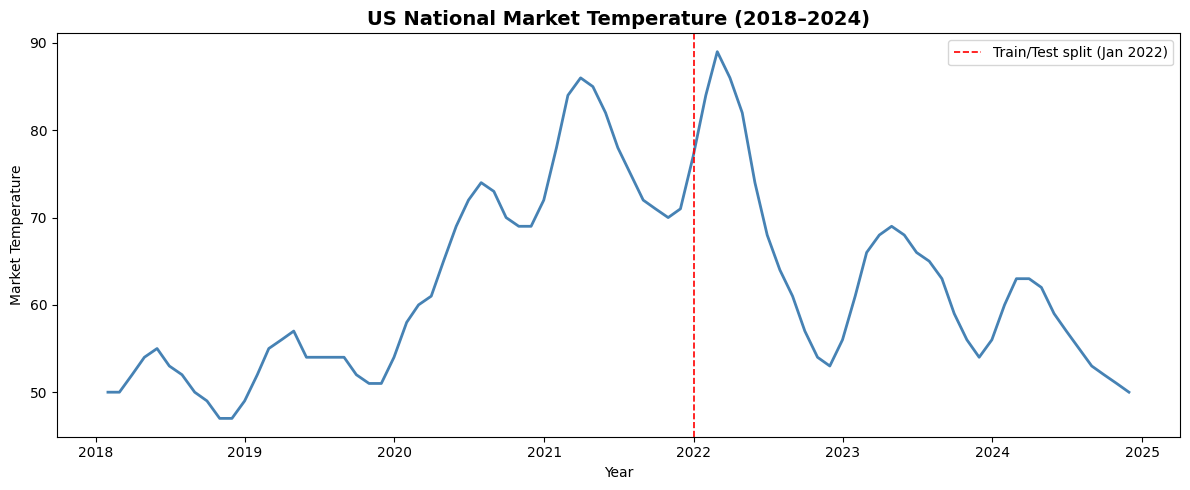

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(us_temp.index, us_temp['MarketTemperature'], color='steelblue', linewidth=2)

ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--', linewidth=1.2, label='Train/Test split (Jan 2022)')

ax.set_title('US National Market Temperature (2018–2024)', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Market Temperature')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

Plotting median sale prices for US

In [47]:
us_price = df_sale_price_updated[
    (df_sale_price_updated['RegionName'] == 'United States') & 
    (df_sale_price_updated['RegionType'] == 'country')
]

In [48]:
us_price

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,US,170922.0
2008-03-31,102001,0,United States,country,US,175612.0
2008-04-30,102001,0,United States,country,US,177500.0
2008-05-31,102001,0,United States,country,US,180000.0
2008-06-30,102001,0,United States,country,US,185000.0
...,...,...,...,...,...,...
2024-06-30,102001,0,United States,country,US,369000.0
2024-07-31,102001,0,United States,country,US,361000.0
2024-08-31,102001,0,United States,country,US,360000.0


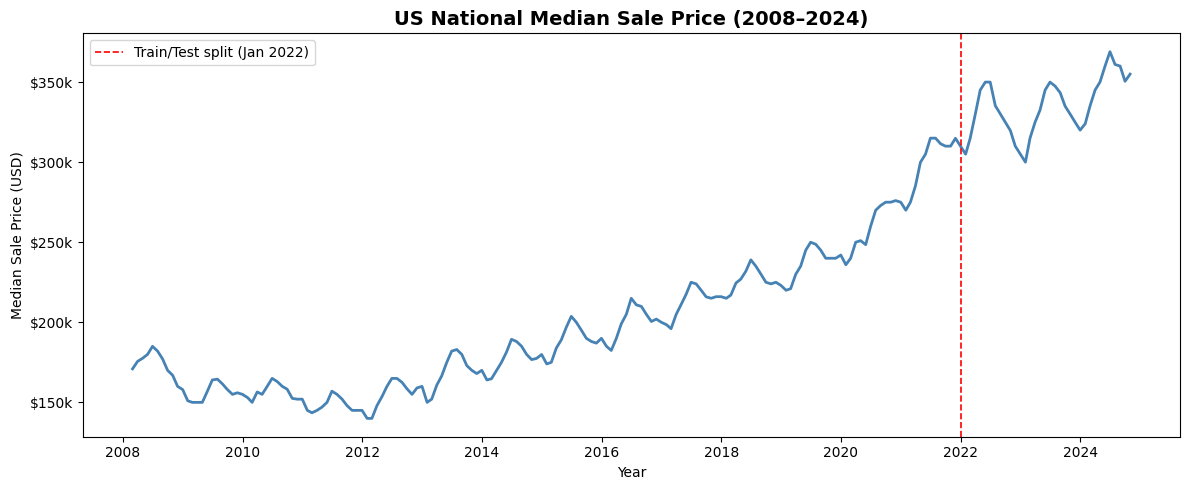

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(us_price.index, us_price['MedianSalePrice'], color='steelblue', linewidth=2)

ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle='--', linewidth=1.2, label='Train/Test split (Jan 2022)')

ax.set_title('US National Median Sale Price (2008–2024)', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Sale Price (USD)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

## HEATMAP CORRELATION

The heatmap all over states is very crowded and difficult to analyse in detail. However, it confirms the general national trend:<br> 
median sale prices have increased across virtually all states over time, with the most visible acceleration occurring after 2020.


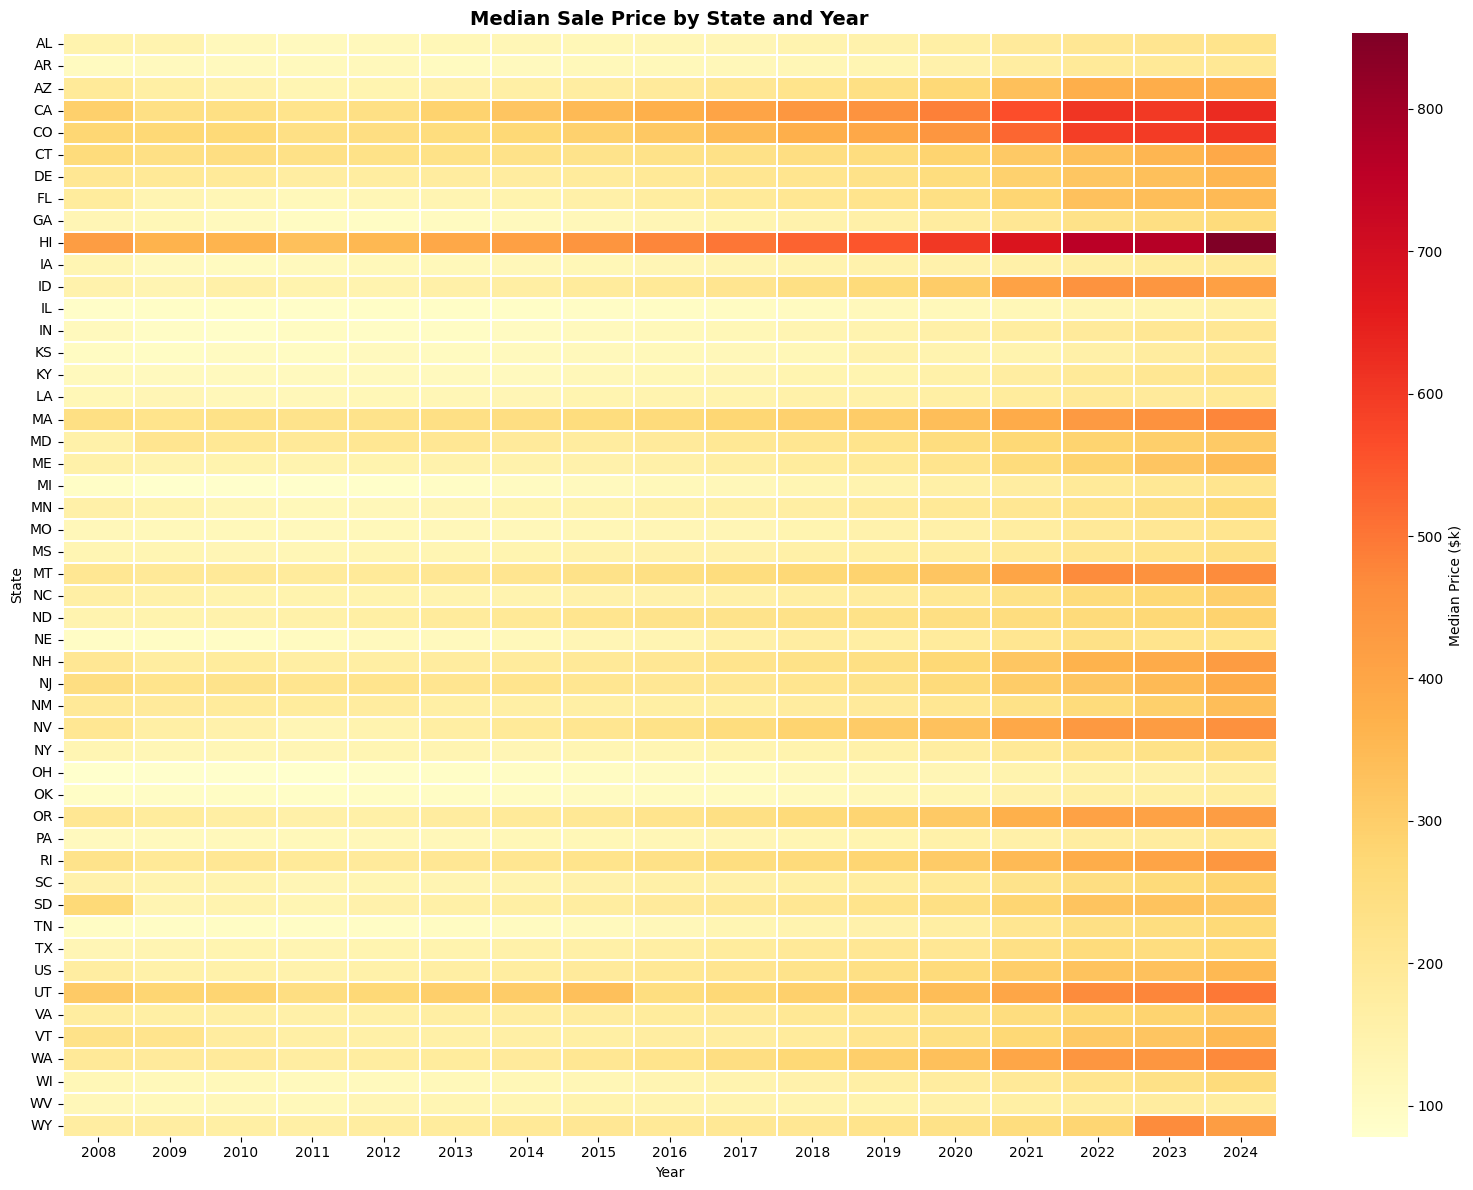

In [51]:
# Pivot: states as rows, years as columns, mean price as values
heatmap_data = (df_sale_price_updated
                .reset_index()
                .assign(Year=lambda x: x['Date'].dt.year)
                .groupby(['StateName', 'Year'])['MedianSalePrice']
                .mean()
                .unstack('Year'))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(heatmap_data/1000, cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Median Price ($k)'})
ax.set_title('Median Sale Price by State and Year', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

## FREQUENCY ANALYSIS

### Power Spectral Density

The PSD on raw data, as we can see above, shows continuously increasing power toward longer periods, with no identifiable peak.<br> This means that there is a strong upward trend and it dominates the frequency spectrum and makes it impossible to detect any shorter cycles like annual seasonality. <br>
To solve this problem we should detrend the data before proceeding with frequency analysis. 

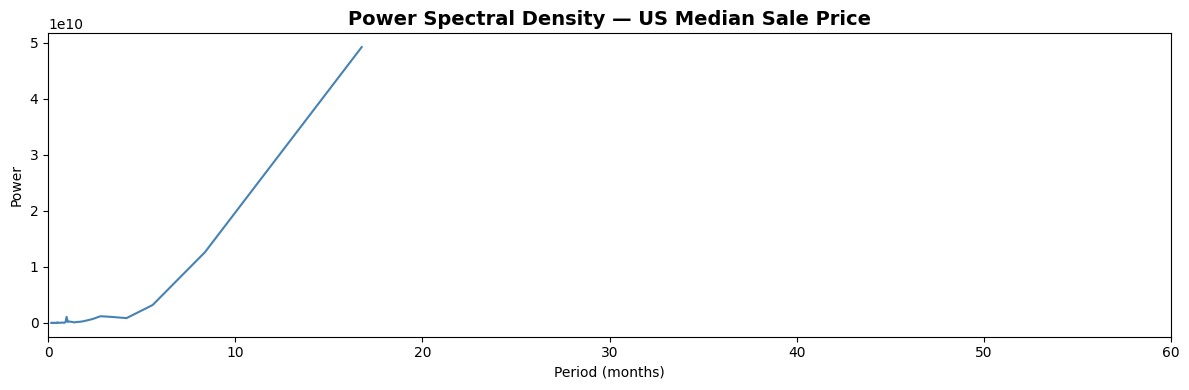

In [52]:
# Use the US national price series, drop NaN
us_values = us_price['MedianSalePrice'].dropna().values

# Compute periodogram (sampling frequency = 12 per year since monthly data)
freqs, psd = signal.periodogram(us_values, fs=12)

# Convert frequency to period in months
periods = 1 / freqs[1:]  # skip zero frequency
psd = psd[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, psd, color='steelblue', linewidth=1.5)
ax.set_title('Power Spectral Density — US Median Sale Price', fontsize=14, weight='bold')
ax.set_xlabel('Period (months)')
ax.set_ylabel('Power')
ax.set_xlim(0, 60)  # focus on periods up to 5 years
plt.tight_layout()
plt.show()

### Detrending data -> *np.diff()*

In [53]:
us_values = us_price['MedianSalePrice'].dropna().values

# Difference the series to remove the long-term trend
us_values_diff = np.diff(us_values)  

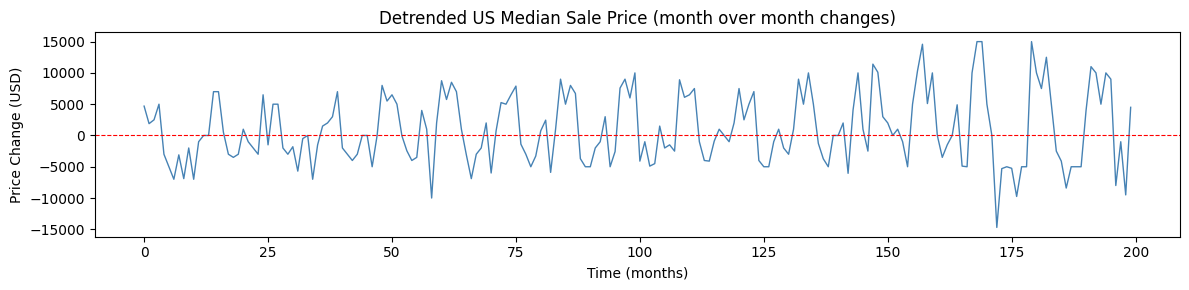

In [54]:
# plot detrended data
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(us_values_diff, color='steelblue', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Detrended US Median Sale Price (month over month changes)')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Price Change (USD)')
plt.tight_layout()
plt.show()

### PSD on detrended data

From the plot we see that there are no clear peak at periods 6 or 12, means that there is no semi-annual or annual seasonality at the national aggregate US level. <br>
Since we check it on average prices across all US regions this result is expected. Because maybe some states have peak prices in summer, <br> others have different patterns, and when we combine them all into one national number they cancel each other out. <br>
Doing individual exploration over different states can show more clear seasonality. -> step 3 and 5 <br>



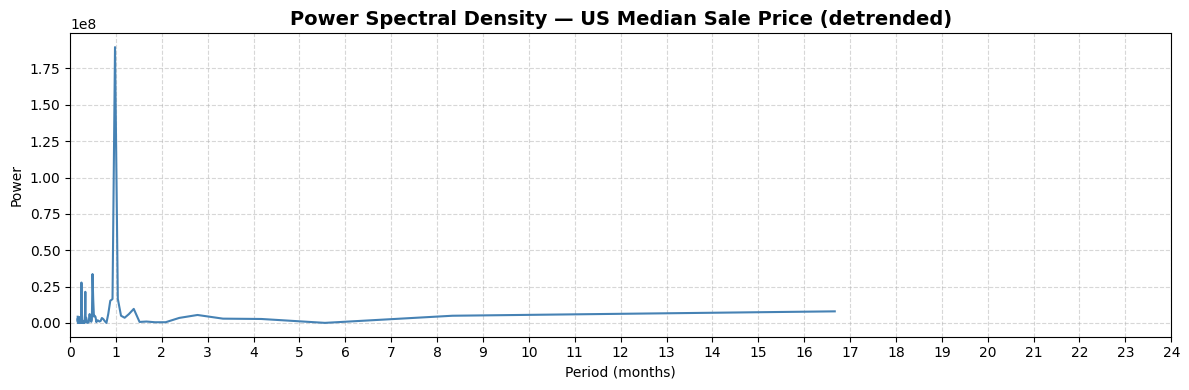

In [55]:
# Compute periodogram
freqs, psd = signal.periodogram(us_values_diff, fs=12)

# Convert frequency to period in months
periods = 1 / freqs[1:]     # skip freq=0 to avoid division by zero
psd = psd[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, psd, color='steelblue', linewidth=1.5)
ax.set_title('Power Spectral Density — US Median Sale Price (detrended)', fontsize=14, weight='bold')
ax.set_xlabel('Period (months)')
ax.set_ylabel('Power')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 1))  
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### ACF Autocorrelation Function -> "How correlated is the series with itself at different time lags?"

*Looking at the plot we can see some short-term autocorrelation (es. this month affects the next month) at lag 1-4,<br> 
and also shows significant spikes at lags 12, 24, and 36 which is a classic signature of annual seasonality.<br> 
We can say that house prices follow a repeating yearly cycle at the national aggregate level.*

>It seems like PSD and ACF contradict, because the PSD did not show a clear peak at period 12, which is consistent.<br> Remember that PSD detects only clean regular cycles, while ACF captures broader repeating correlations.<br> Together they suggest seasonality exists but is irregular in amplitude across years.

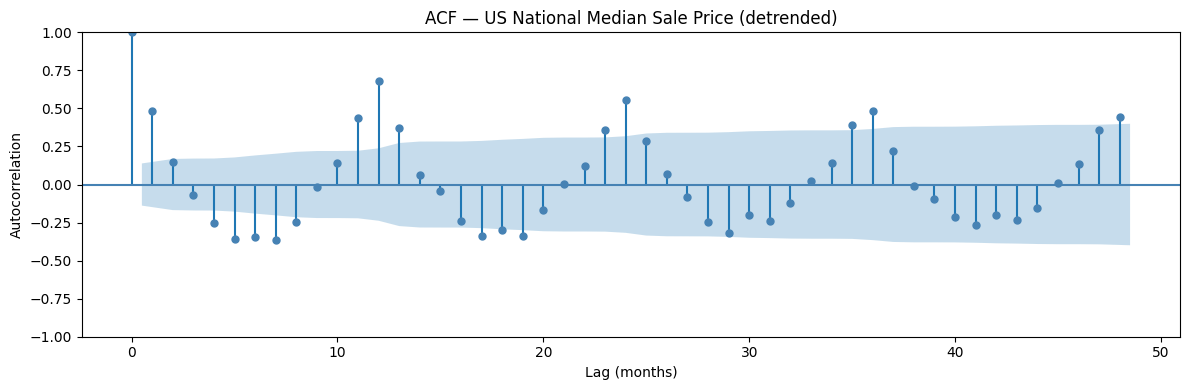

In [56]:
fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(us_values_diff, 
         lags=48,
         ax=ax,
         color='steelblue',
         title='ACF — US National Median Sale Price (detrended)')

ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

# 3. Focusing on 5 different US states , describing the time series patterns (visually and numerically)

Remmeber that the 5 states are already selected in step1, based on different criteria.

In [57]:
selected_states = {
    'NC': 'North Carolina',
    'CA': 'California',
    'WA': 'Washington',
    'TX': 'Texas',
    'PA': 'Pennsylvania'
}

## Time series plot for each state

Observation from plots below: 
- We can see that some states have expensive markets, such as : Washington and California, and others  are cheaper than those. Indeed, we can see that the NC, TX and PA have similar prices. 
- All 5 states share the same story: flat/slow 2008–2016, steady growth 2016–2020, sharp acceleration 2020–2022, then some leveling off post split.
- California and Washington show the smoothest, most consistent upward trends.
- Texas and North Carolina are noisier.
- Pennsylvania shows the most visible regular oscillations, hinting at a seasonal pattern.
- After 2022: 
    - North Carolina and Texas continue climbing even after 2022. 
    - California and Washington flatten noticeably. 
    - Pennsylvania keeps its oscillating pattern but at a higher price level. 

In [58]:
# train and test sets for selected states only 
states_train = {state: median_sale_train[median_sale_train['StateName'] == state]
                .groupby(level=0)['MedianSalePrice'].mean()
                for state in selected_states}

states_test = {state: median_sale_test[median_sale_test['StateName'] == state]
               .groupby(level=0)['MedianSalePrice'].mean()
               for state in selected_states}

In [59]:
# states_train

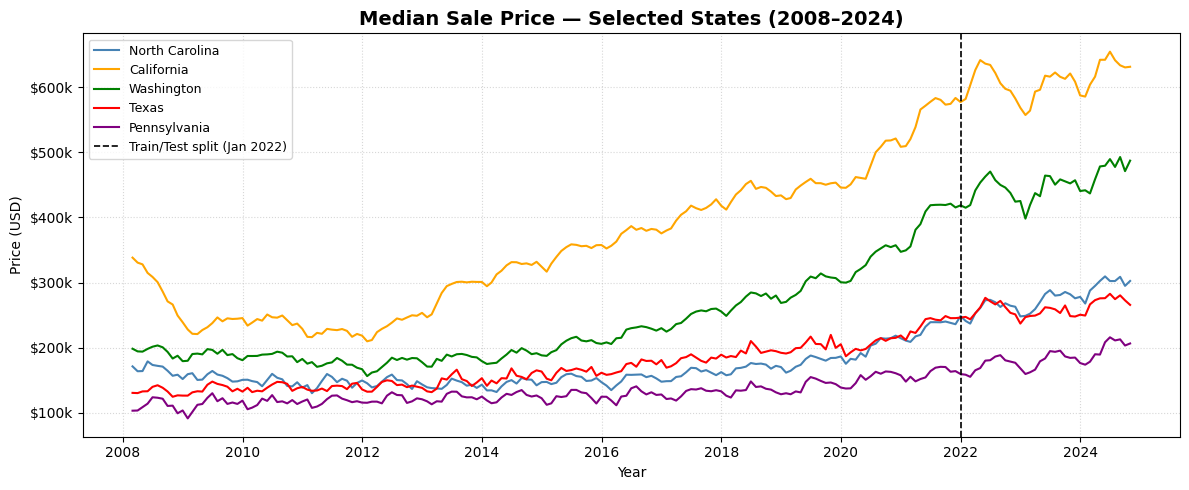

In [60]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['steelblue', 'orange', 'green', 'red', 'purple']

for (state, full_name), color in zip(selected_states.items(), colors):
    full_series = pd.concat([states_train[state], states_test[state]])
    ax.plot(full_series.index, full_series.values, 
            color=color, linewidth=1.5, label=full_name)

ax.axvline(pd.Timestamp('2022-01-01'), color='black', linestyle='--', 
           linewidth=1.2, label='Train/Test split (Jan 2022)')

ax.set_title('Median Sale Price — Selected States (2008–2024)', fontsize=14, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Check lags for each state

I decided to plot 4 lags: 
- lag1: to see if the next month predictable from this month;
- lag3: to see quarterly relationship
- Lag6: semi-annual correlation
- Lag12: annual correlation to see if this year's price correlate with same month last year

Observations: 
- All states show a clear linear pattern at every lag, confirming that the data is not random and that current prices are strongly predictable from past prices. 
- Lag1: tightest across all states, means that last month's price is an almost perfect predictor of this month's price
- When lag increase the scatter is wider, we can see that the diagonal pattern loosens progressively from lag 1 to lag 12, this means that the further back we look,<br>the less precise the relationship. But,still clearly linear though, never a random cloud.
- I also want to precise that Pennsylvania shows the most spread at lag 6 and lag 12, the points are more dispersed around the diagonal compared to other states,<br>
 which highlights at a seasonal cycle disrupting the simple lag relationship. We can confirm that this behaviour is consistent with the oscillating pattern visible in the time series plot.

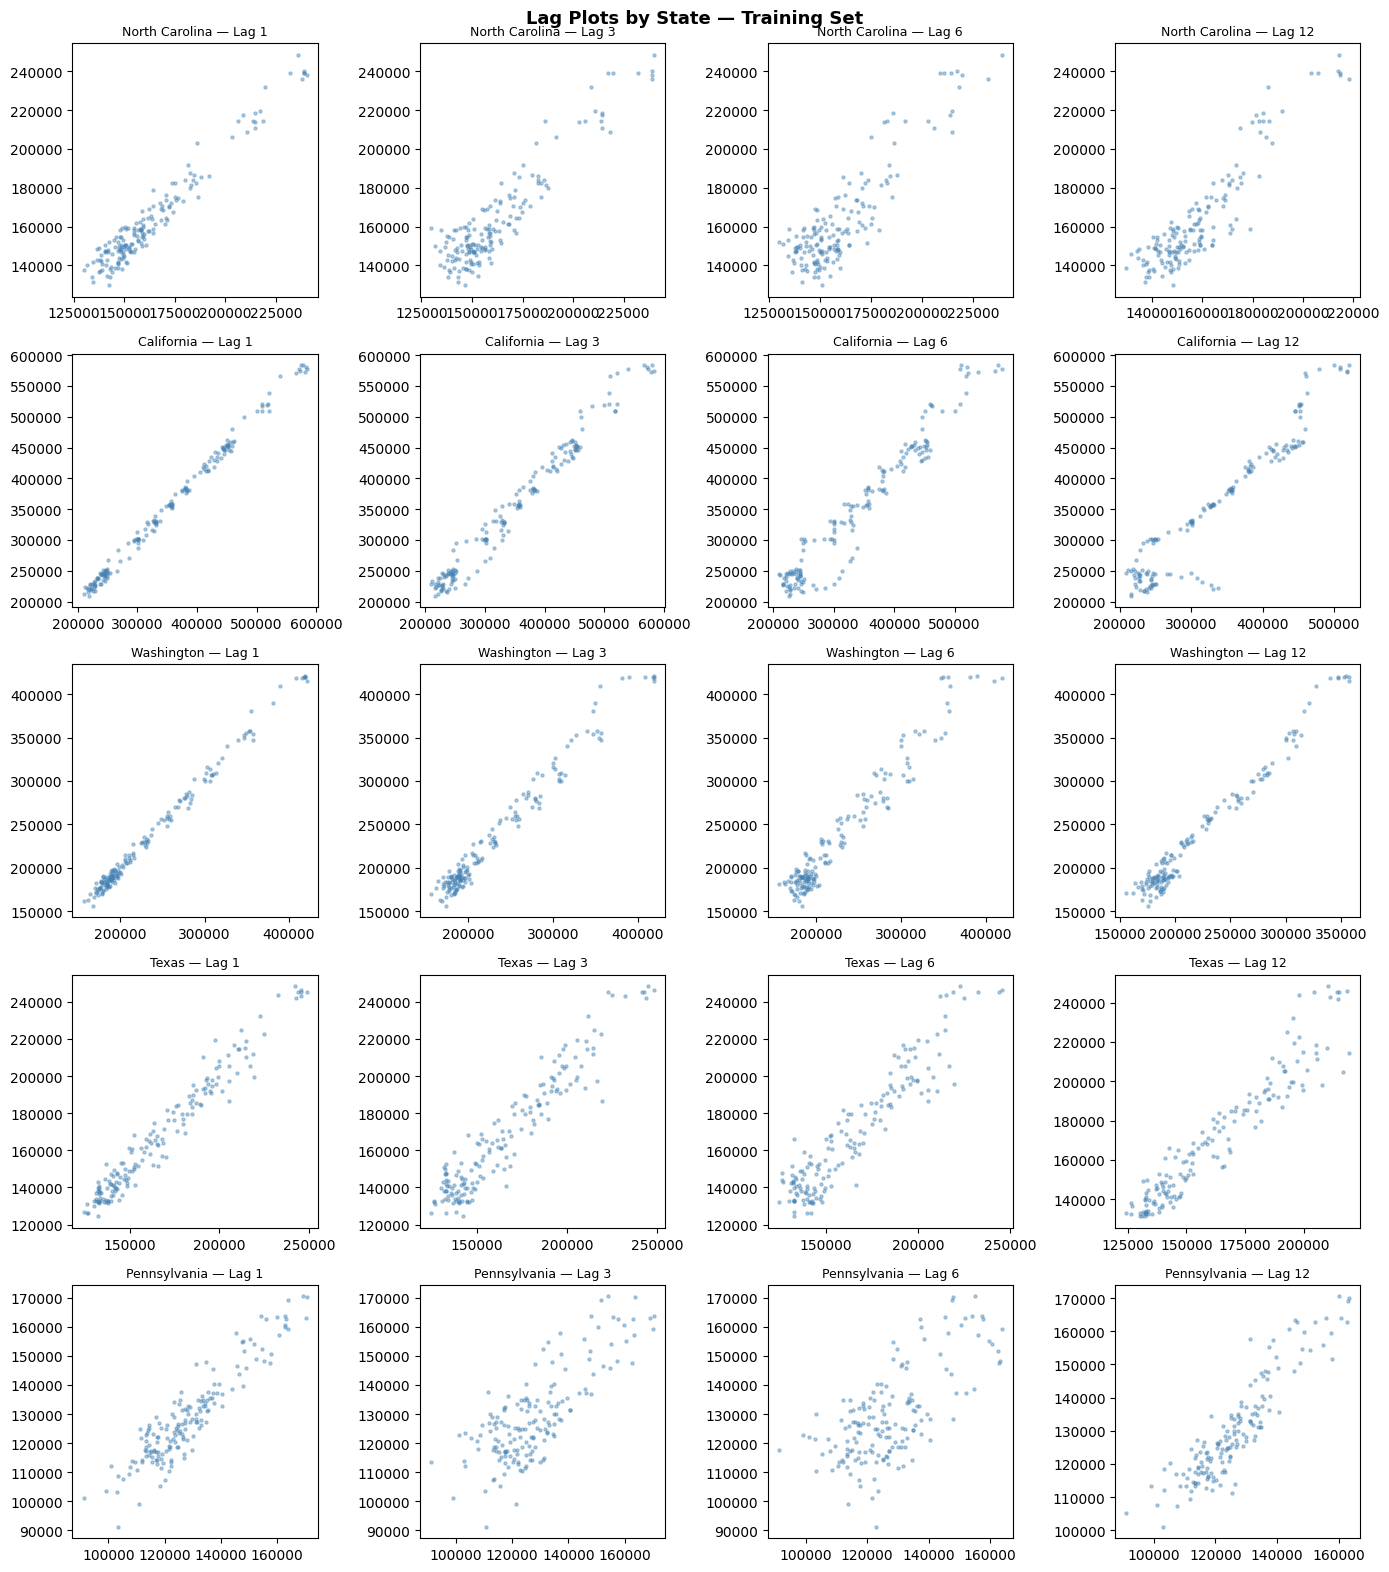

In [62]:
lags_to_plot = [1, 3, 6, 12]

fig, axes = plt.subplots(5, 4, figsize=(14, 16))

for row, (state, full_name) in enumerate(selected_states.items()):
    for col, lag in enumerate(lags_to_plot):
        lag_plot(states_train[state], lag=lag, ax=axes[row, col],
                 c='steelblue', alpha=0.4, s=5)
        axes[row, col].set_title(f'{full_name} — Lag {lag}', fontsize=9)
        axes[row, col].set_xlabel('')
        axes[row, col].set_ylabel('')

plt.suptitle('Lag Plots by State — Training Set', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## Check ACF+PACF

**ACF** of all 5 states:<br>
All show a slowly and gradually decreasing over 48 lags with almost non ever dropping to zero. This is the classic signature of a non-stationary trending series. <br>
The series has long memory. For example, prices from 2 years ago are still correlated with today's prices, simply because of the persistent upward trend.<br>
Some states (notably PA and NC) show mild bumps at lags 12 and 24, suggesting weak annual seasonality, but the trend dominates.


**PACF** of all 5 states:<br>
All show a large spike at lag 1, then an immediate drop to near zero for all subsequent lags. This is the classic AR(1) signature, <br> 
only the immediately preceding month has a direct effect on the current price. Everything else is indirect. <br> 
Pennsylvania is the exception, with additional spikes outside the confidence band at lags 6, 9, and 10, suggesting a more complex autoregressive structure.

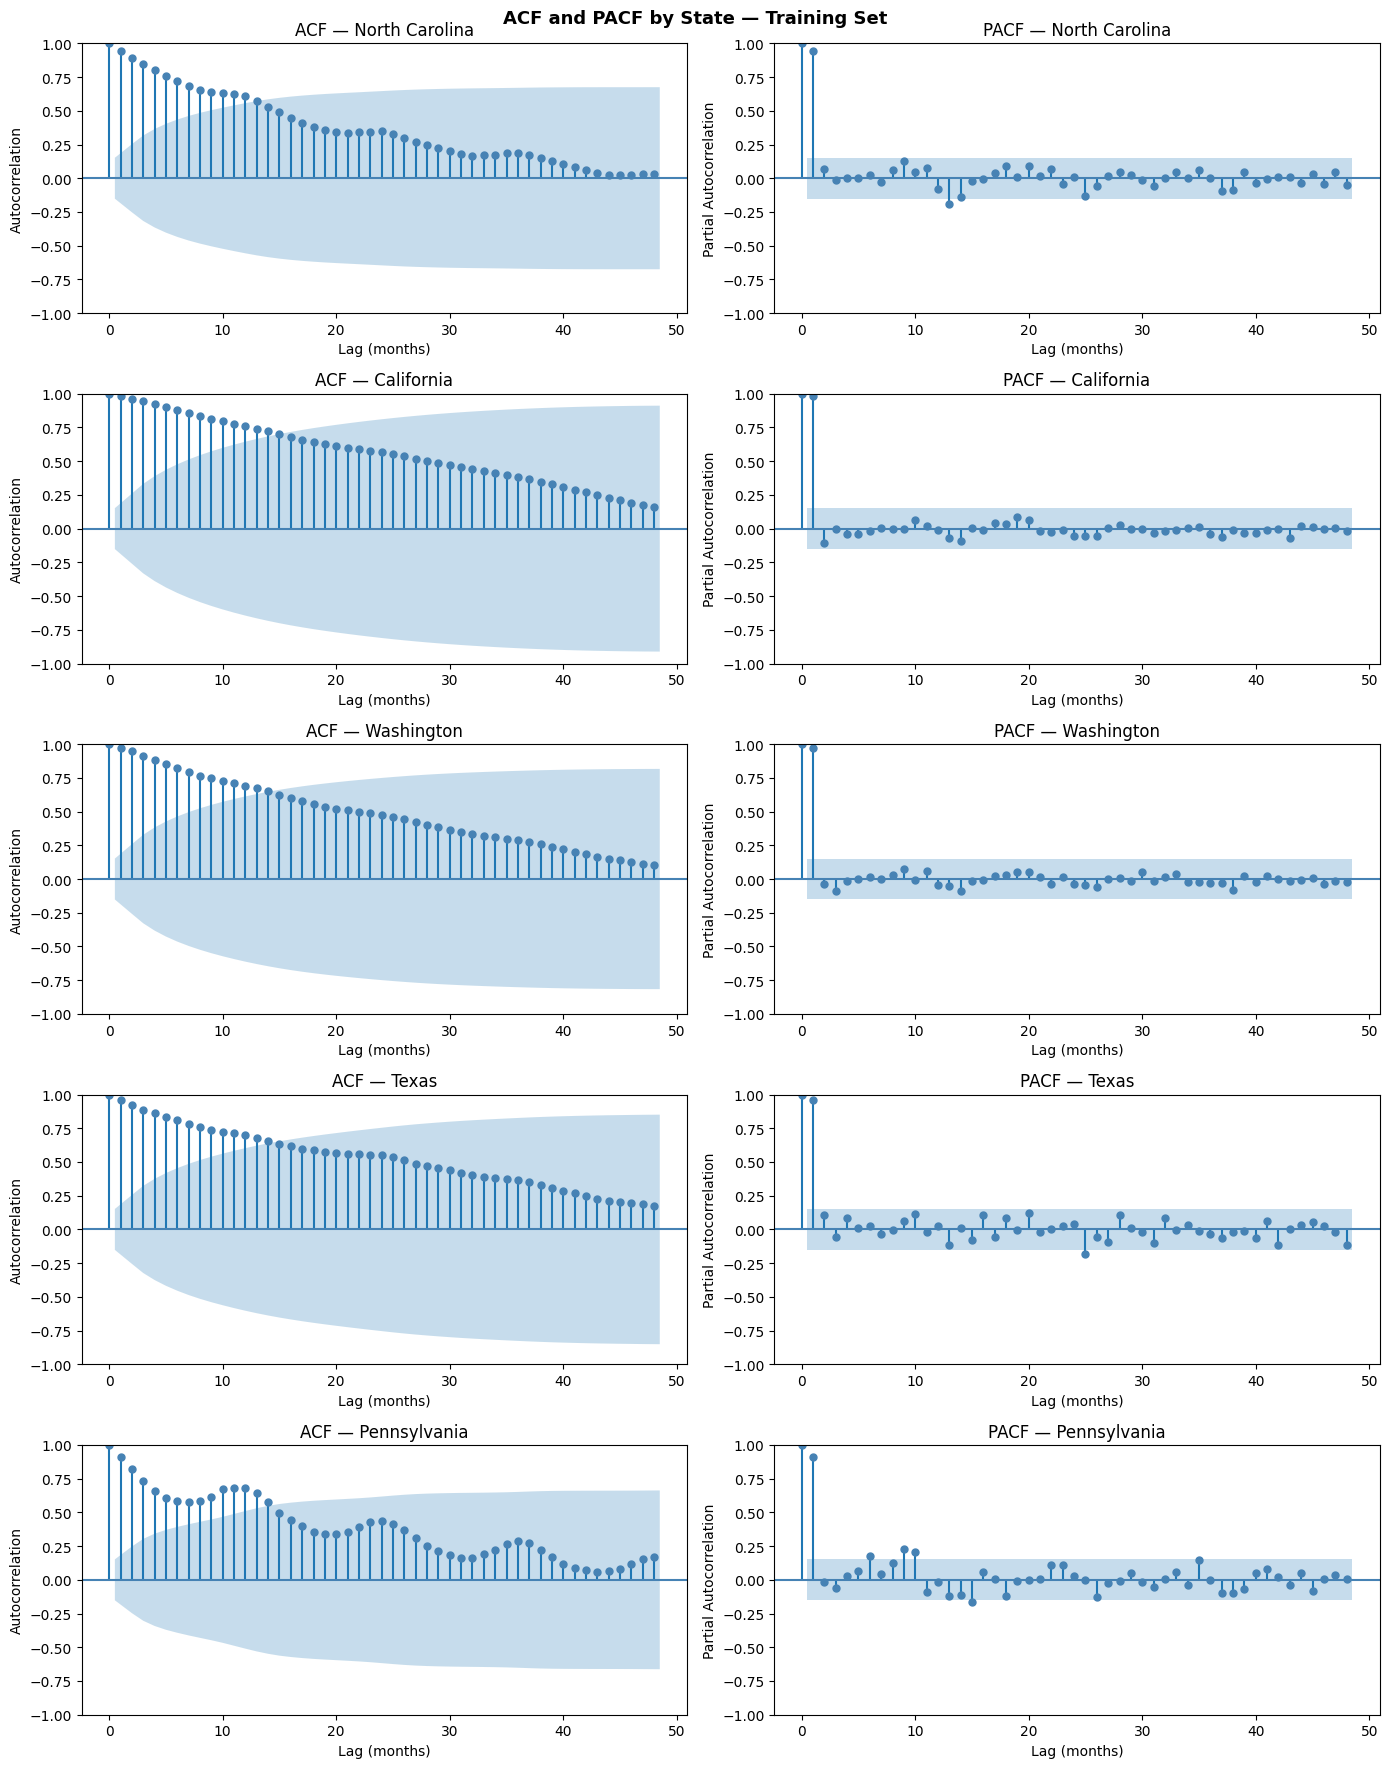

In [63]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for row, (state, full_name) in enumerate(selected_states.items()):
    # ACF
    plot_acf(states_train[state], lags=48, ax=axes[row, 0],
             color='steelblue', title=f'ACF — {full_name}')
    axes[row, 0].set_xlabel('Lag (months)')
    axes[row, 0].set_ylabel('Autocorrelation')

    # PACF
    plot_pacf(states_train[state], lags=48, ax=axes[row, 1],
              color='steelblue', title=f'PACF — {full_name}')
    axes[row, 1].set_xlabel('Lag (months)')
    axes[row, 1].set_ylabel('Partial Autocorrelation')

plt.suptitle('ACF and PACF by State — Training Set', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## Seasonal decomposition


**North Carolina:**
Trend decrease until ~2012 then recovers steadily, accelerating sharply from 2016. Seasonal component shows a stable ±$7.5k annual cycle throughout the entire period. <br> Residual fluctuates between -$15k and +$10k with no clear pattern, indicating unexplained variability remains after decomposition.

**California:**
Trend dips from ~$250k to ~$230k until around 2012, then grows continuously, accelerating sharply post-2012 and reaching $550k+. <br> Seasonal amplitude is ±$10-15k, consistent across the full period. Residual shows high variability across the entire period ranging from -$25k to +$15k, suggesting persistent unexplained variability beyond trend and seasonality.

**Washington:**
Trend grows from ~$190k to $400k+, with a similar acceleration pattern to California. Seasonal cycle is between at -10k and +$7.5k. <br> Residual stays within ±$10k for most of the period, with a moderate positive spike around 2020.

**Texas:**
Trend grows consistently from ~$130k to $240k+ with no visible dip in the early period unlike NC and CA. Seasonal component is stable at ±$8k throughout. <br> Residual is contained within ±$15k, with larger fluctuations appearing from 2018 onward.

**Pennsylvania:**
Pennsylvania shows the slowest overall price growth of all 5 states, from ~$110k to ~$160k, with a brief flattening around 2012–2014 before accelerating from 2018 onward. <br> The seasonal component is between at -$7.5k and +$10k throughout the entire period. The residual shows irregular behavior throughout the period, with clusters of larger swings around 2009-2010, 2015-2016 and 2020-2021, suggesting the decomposition did not fully capture all the variability in the series. -> consistent with why Pennsylvania's PACF showed additional spikes beyond lag 1 

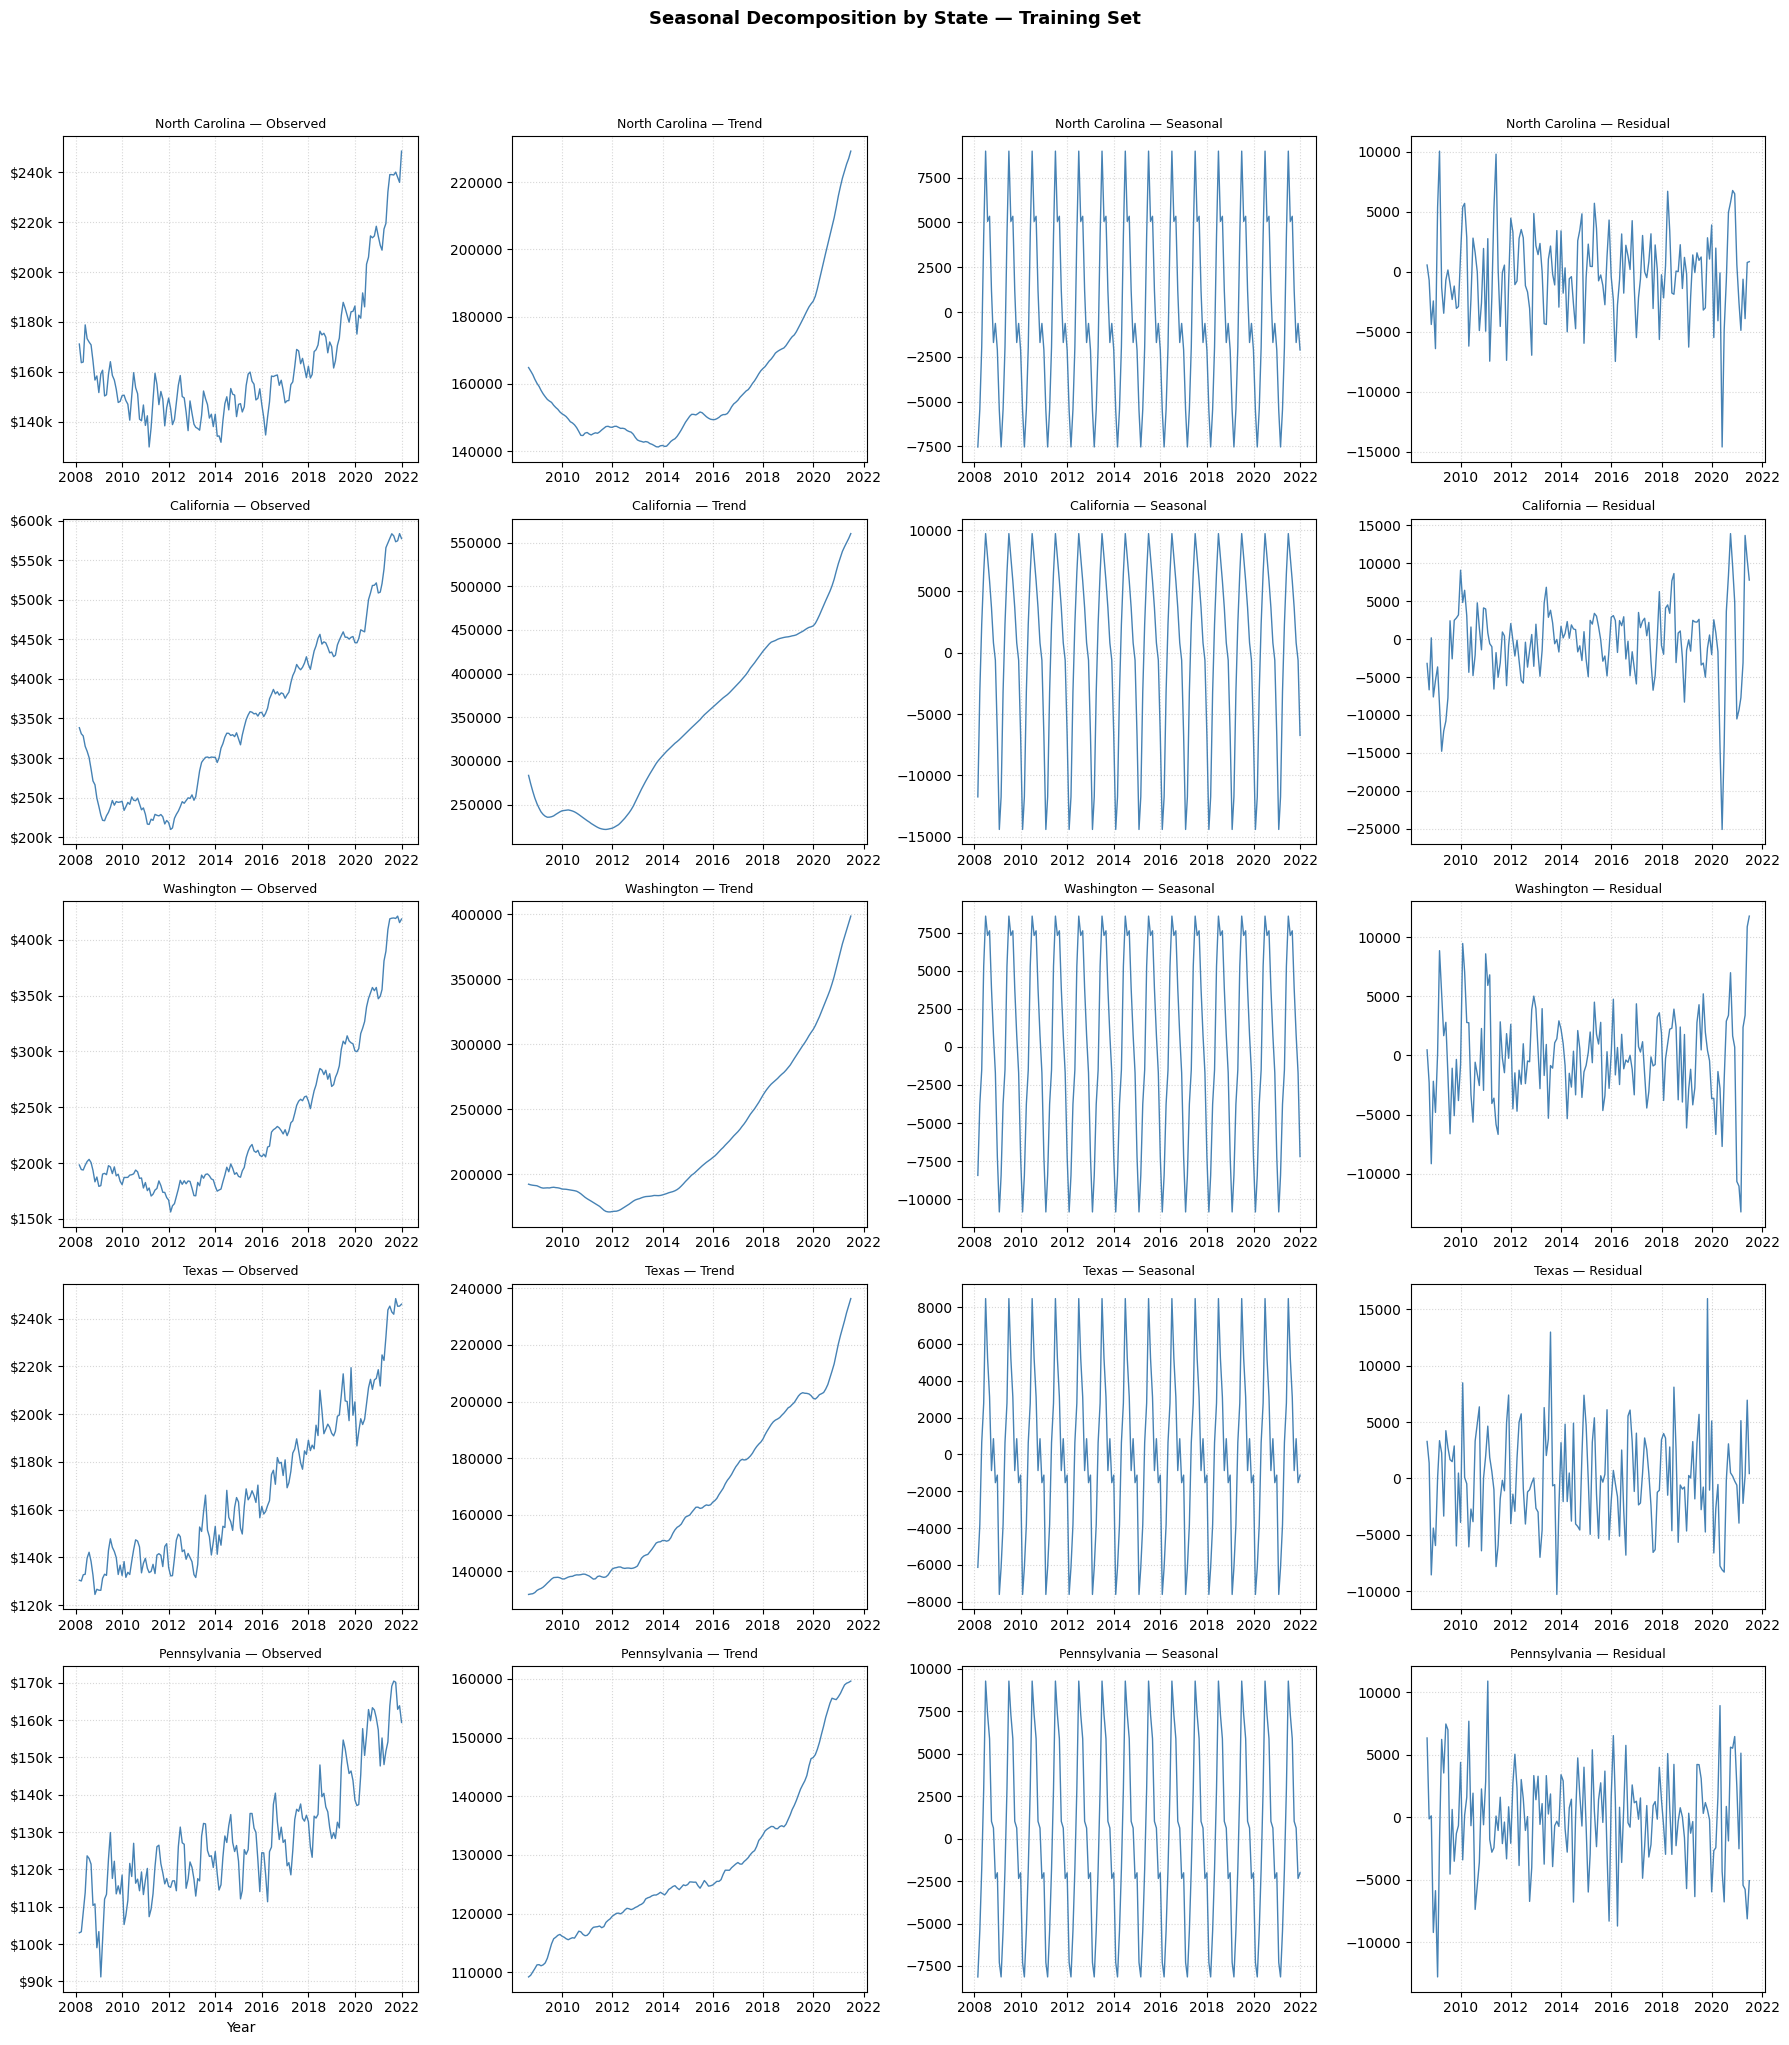

In [64]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))

for row, (state, full_name) in enumerate(selected_states.items()):
    decomposition = seasonal_decompose(states_train[state], 
                                       model='additive', 
                                       period=12)
    
    components = {
        'Observed':  decomposition.observed,
        'Trend':     decomposition.trend,
        'Seasonal':  decomposition.seasonal,
        'Residual':  decomposition.resid
    }
    
    for col, (name, series) in enumerate(components.items()):
        axes[row, col].plot(series.index, series.values, 
                           color='steelblue', linewidth=1)
        axes[row, col].set_title(f'{full_name} — {name}', fontsize=9)
        axes[row, col].grid(True, linestyle=':', alpha=0.5)
        if col == 0:
            axes[row, col].yaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

axes[-1][0].set_xlabel('Year')
plt.suptitle('Seasonal Decomposition by State — Training Set', 
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

## Stationarity Test

**ADF** null hypothesis = series IS non-stationary. p-value close to 1.0 → we FAIL to reject the null → series is non-stationary 

**KPSS** null hypothesis = series IS stationary. p-value ≤ 0.01 → we REJECT the null → series is non-stationary 

This non stationarity is confirmed also by **Rolling Mean & Standard Deviation** plot, as we can see that the rolling mean is not flat 
- If the series is stationary → rolling mean and std should be flat and constant over time
- If non-stationary → rolling mean and/or std will drift or change over time

In [65]:
def check_stationarity(series, state_name):
    # ADF test
    adf_stat, adf_pvalue, _, _, adf_crit, _ = adfuller(series.dropna())
    adf_result = 'Stationary' if adf_pvalue < 0.05 else 'Non-stationary'
    
    # KPSS test
    kpss_stat, kpss_pvalue, _, kpss_crit = kpss(series.dropna(), regression='c')
    kpss_result = 'Non-stationary' if kpss_pvalue < 0.05 else 'Stationary'
    
    return {
        'State': state_name,
        'ADF Statistic': round(adf_stat, 4),
        'ADF p-value': round(adf_pvalue, 4),
        'ADF Result': adf_result,
        'KPSS Statistic': round(kpss_stat, 4),
        'KPSS p-value': round(kpss_pvalue, 4),
        'KPSS Result': kpss_result
    }

# run for all 5 states
results = []
for state, full_name in selected_states.items():
    results.append(check_stationarity(states_train[state], full_name))

stationarity_df = pd.DataFrame(results)
print(stationarity_df.to_string(index=False))

         State  ADF Statistic  ADF p-value     ADF Result  KPSS Statistic  KPSS p-value    KPSS Result
North Carolina         2.3161       0.9990 Non-stationary          1.1577          0.01 Non-stationary
    California         0.9600       0.9938 Non-stationary          1.7741          0.01 Non-stationary
    Washington         2.8192       1.0000 Non-stationary          1.5749          0.01 Non-stationary
         Texas         2.0499       0.9987 Non-stationary          1.8388          0.01 Non-stationary
  Pennsylvania         2.5825       0.9991 Non-stationary          1.6872          0.01 Non-stationary


/tmp/ipykernel_12536/3617554934.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_crit = kpss(series.dropna(), regression='c')
/tmp/ipykernel_12536/3617554934.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_crit = kpss(series.dropna(), regression='c')
/tmp/ipykernel_12536/3617554934.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_crit = kpss(series.dropna(), regression='c')
/tmp/ipykernel_12536/3617554934.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. T

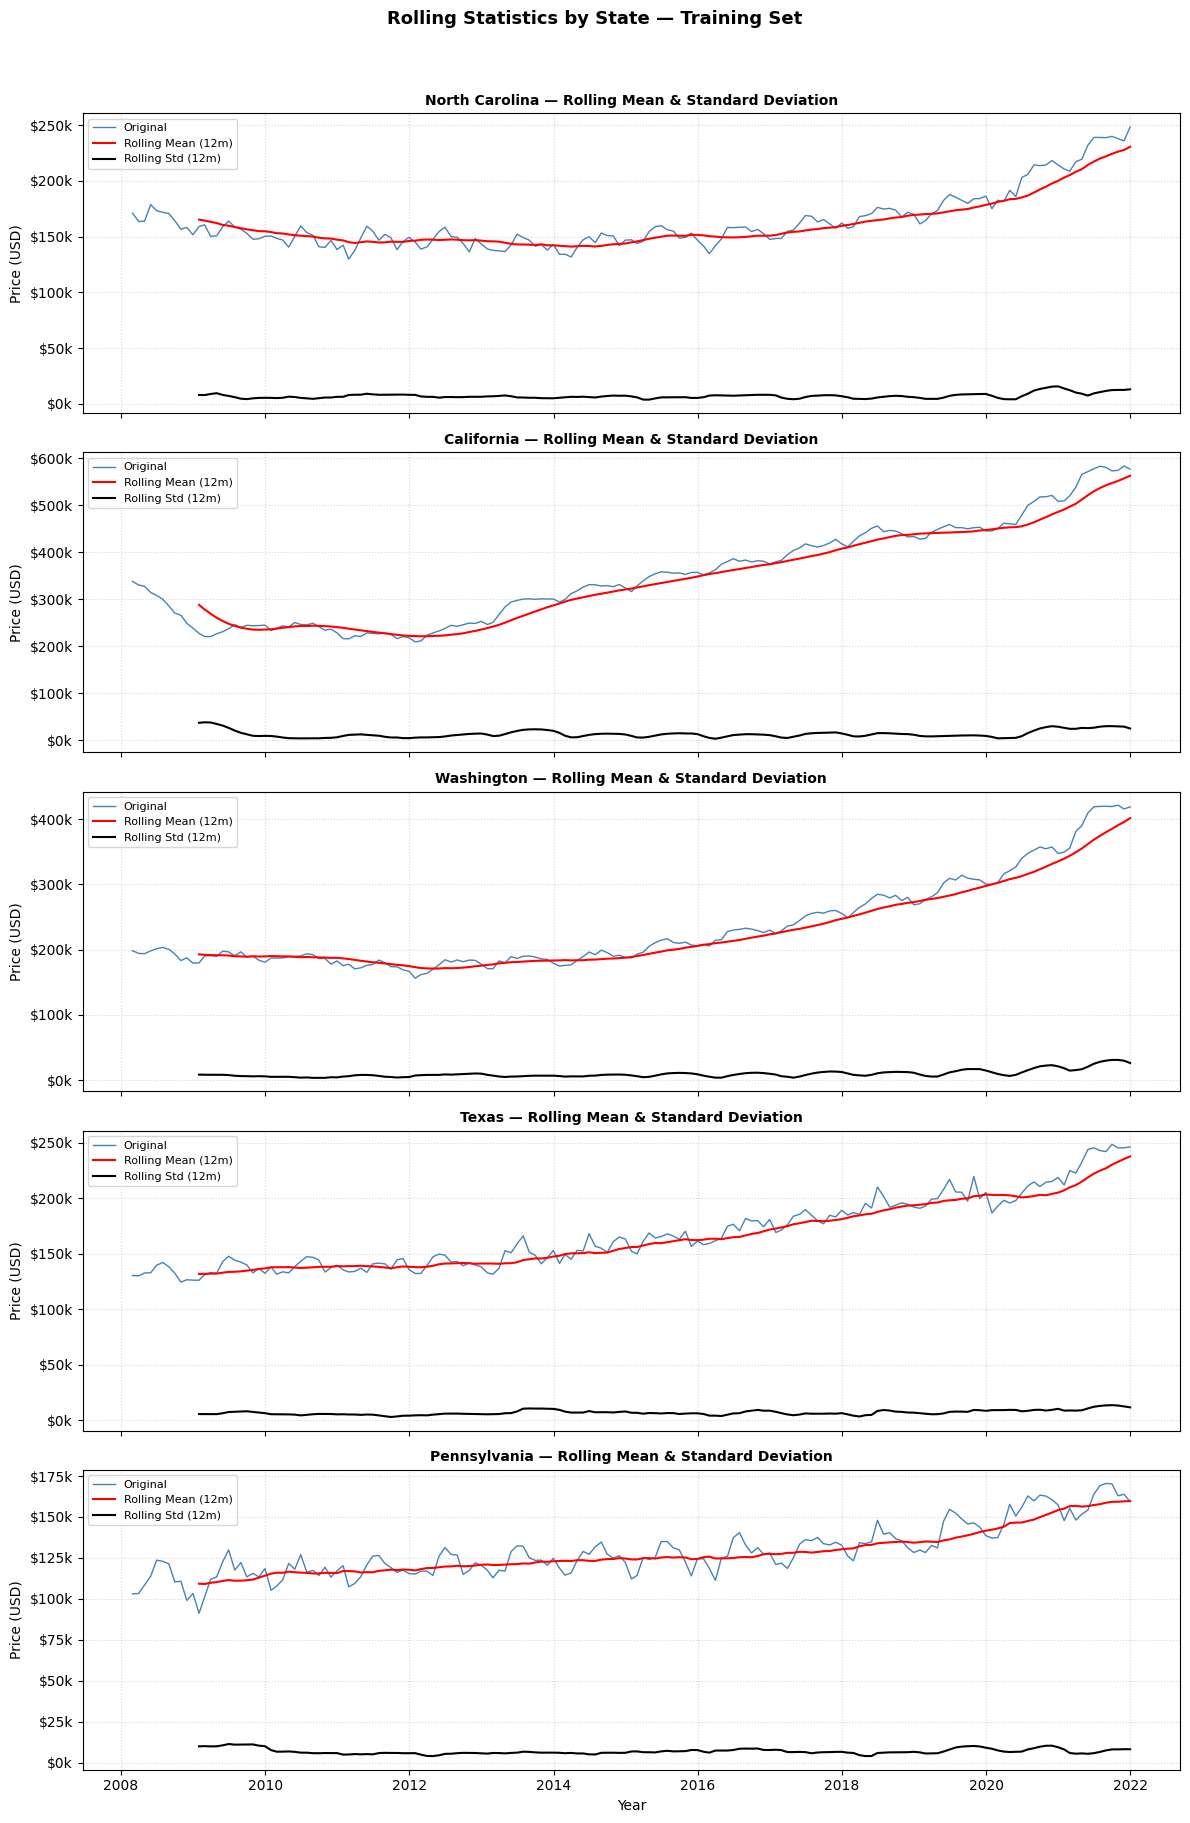

In [66]:
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

for ax, (state, full_name) in zip(axes, selected_states.items()):
    series = states_train[state].dropna()
    rolling_mean = series.rolling(window=12).mean()
    rolling_std = series.rolling(window=12).std()
    
    ax.plot(series.index, series.values, color='steelblue', linewidth=1, label='Original')
    ax.plot(rolling_mean.index, rolling_mean.values, color='red', linewidth=1.5, label='Rolling Mean (12m)')
    ax.plot(rolling_std.index, rolling_std.values, color='black', linewidth=1.5, label='Rolling Std (12m)')
    
    ax.set_title(f'{full_name} — Rolling Mean & Standard Deviation', fontsize=10, weight='bold')
    ax.set_ylabel('Price (USD)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Year')
plt.suptitle('Rolling Statistics by State — Training Set', fontsize=13, weight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

## Summary Statistic Table

**Mean price:** California has by far the highest average price ($350.7k)<br>
Pennsylvania has the lowest mean ($128.6k), reflecting its slower and more modest market.

**Volatility (Std):** California shows the highest standard deviation ($104.5k), meaning prices varied the most over the training period. <br> 
Pennsylvania is the most stable with only $15.8k std, the least volatile market of the 5 states.

**Min/Max range:** California spans from $209.7k to $583.6k, the widest absolute price range. <br> 
Pennsylvania has the narrowest range ($91.2k to $170.5k), consistent with its slow steady growth.

**Total growth:** Washington shows the strongest total price growth at **111.14%** , prices more than doubled from start to end. <br> 
California follows at 70.67%. Pennsylvania and North Carolina show more moderate growth at 54.68% and 45.19% respectively. Texas sits in between at 88.71%.



In [67]:
summary_stats = []

for state, full_name in selected_states.items():
    series = states_train[state].dropna()
    growth = ((series.iloc[-1] - series.iloc[0]) / series.iloc[0] * 100).round(2)
    
    summary_stats.append({
        'State':          full_name,
        'Mean ($k)':      round(series.mean() / 1000, 1),
        'Std ($k)':       round(series.std() / 1000, 1),
        'Min ($k)':       round(series.min() / 1000, 1),
        'Max ($k)':       round(series.max() / 1000, 1),
        'Total Growth %': growth
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

         State  Mean ($k)  Std ($k)  Min ($k)  Max ($k)  Total Growth %
North Carolina      163.4      25.6     129.9     248.5           45.19
    California      350.7     104.5     209.7     583.6           70.67
    Washington      234.2      68.1     156.2     421.2          111.14
         Texas      167.7      32.1     124.4     248.5           88.71
  Pennsylvania      128.6      15.8      91.2     170.5           54.68


# 4. Is there any associations with the market heat index (considering the common time window)?

## Align the two dataset row for row on the same time window, so from January 2018 to October 2024. 

Filter both datasets to the common time window (Jan 2018 to Oct 2024) to prepare for merge.

In [95]:
# common time window
window_start = '2018-01-01'
window_end   = '2024-10-31'


state_abbrevs = list(selected_states.keys())  

prices_window = (
    df_sale_price_updated[
        df_sale_price_updated['StateName'].isin(state_abbrevs) &
        (df_sale_price_updated.index >= window_start) &
        (df_sale_price_updated.index <= window_end)
    ]
    .copy()
)

heat_window = (
    df_market_temp_updated[
        df_market_temp_updated['StateName'].isin(state_abbrevs) &
        (df_market_temp_updated.index >= window_start) &
        (df_market_temp_updated.index <= window_end)
    ]
    .copy()
)

print("Price rows:", len(prices_window))
print("Heat rows: ", len(heat_window))
print("Price date range:", prices_window.index.min(), "→", prices_window.index.max())
print("Heat  date range:", heat_window.index.min(),  "→", heat_window.index.max())

Price rows: 12054
Heat rows:  16154
Price date range: 2018-01-31 00:00:00 → 2024-10-31 00:00:00
Heat  date range: 2018-01-31 00:00:00 → 2024-10-31 00:00:00


## Aggregating to state level and merge

after groupby + mean(), StateName and Date become index levels, not columns.<br>
reset_index() promotes them back to regular columns so that pd.merge() can match rows across the two dataframes on ['StateName', 'Date'].<br>
with this step, merge() can find the keys and wouldn't fail.

In [69]:
prices_agg = (
    prices_window
    .groupby(['StateName', prices_window.index])['MedianSalePrice']
    .mean()
    .reset_index()
    .rename(columns={'Date': 'Date'})  
)
prices_agg.columns = ['StateName', 'Date', 'MedianSalePrice']

heat_agg = (
    heat_window
    .groupby(['StateName', heat_window.index])['MarketTemperature']
    .mean()
    .reset_index()
)
heat_agg.columns = ['StateName', 'Date', 'MarketTemperature']


df_aggregate = pd.merge(prices_agg, heat_agg, on=['StateName', 'Date'], how='inner')
df_aggregate = df_aggregate.sort_values(['StateName', 'Date']).reset_index(drop=True)

# print("Shape after merge:", df_aggregate.shape)
# print("Missing values:\n", df_aggregate.isnull().sum())
print(df_aggregate.head(10))

  StateName       Date  MedianSalePrice  MarketTemperature
0        CA 2018-01-31    412058.333333          54.852941
1        CA 2018-02-28    423533.333333          51.705882
2        CA 2018-03-31    435250.000000          54.323529
3        CA 2018-04-30    441783.333333          57.088235
4        CA 2018-05-31    451266.666667          58.205882
5        CA 2018-06-30    456286.366667          53.882353
6        CA 2018-07-31    443933.333333          50.058824
7        CA 2018-08-31    446851.500000          47.441176
8        CA 2018-09-30    445533.333333          44.294118
9        CA 2018-10-31    439768.966667          43.352941


## Dual axis overlay plot

Plot comments: 

**NC** : Heat index peaked around mid-2021 and declined sharply afterward. Prices continued rising after that point.<br>
The heat index changed direction before prices did, suggesting a potential leading relationship.

**CA** : Very similar pattern to NC. Heat index spiked around 2021–2022 then dropped steeply. Prices peaked at almost same dates, price  line behave like heat line but at the different price level.. <br>

**WA** : Same broad pattern as NC. Heat index peaked around 2021 and declined, while prices kept rising and stabilised later. <br>

**TX** : Follows the same general pattern. Both series show the 2021–2022 boom and subsequent decline, with prices again peaking slightly after the heat index.

**PA** : Both series are noisier and harder to read. The same general structure is present but less clearly defined than the other four states. <br>
Additionally, both indexes show stronger seasonal oscillations throughout compared to other states.

---

Across all 5 states the pattern is consistent, the heat index tends to change direction (peak, then decline) before prices do.<br> 


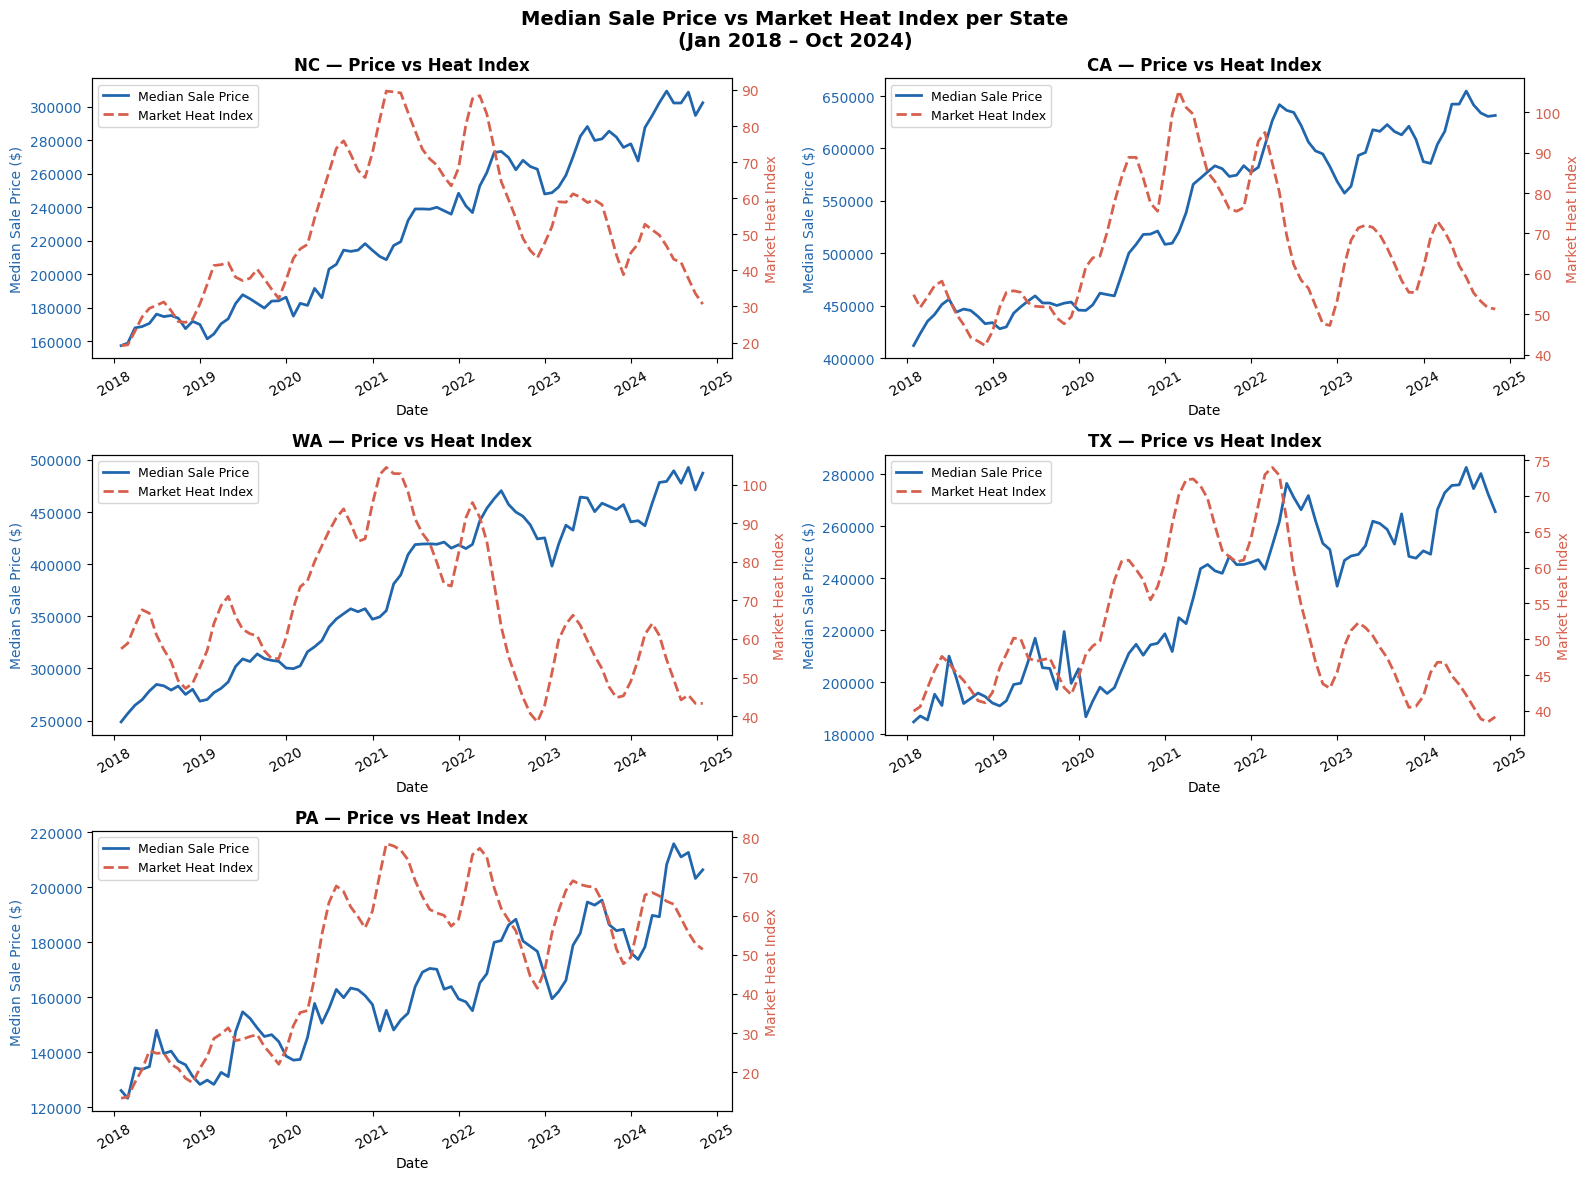

In [70]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

color_price = '#2166ac'
color_heat  = '#d6604d'

for i, abbrev in enumerate(selected_states.keys()):
    ax1 = axes[i]
    ax2 = ax1.twinx()   # With ***twinx()*** we create a second y-axis that shares the same x-axis: 
                        # this is step is essential because price (dollars) and heat index have
                        # completely different scales, so putting them on one axis would flatten one series visually

    state_df = df_aggregate[df_aggregate['StateName'] == abbrev].copy()

    ax1.plot(state_df['Date'], state_df['MedianSalePrice'],
             color=color_price, linewidth=2, label='Median Sale Price')
    ax2.plot(state_df['Date'], state_df['MarketTemperature'],
             color=color_heat, linewidth=2, linestyle='--', label='Market Heat Index')

    ax1.set_title(f'{abbrev} — Price vs Heat Index', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Median Sale Price ($)', color=color_price)
    ax2.set_ylabel('Market Heat Index', color=color_heat)
    ax1.tick_params(axis='y', labelcolor=color_price)
    ax2.tick_params(axis='y', labelcolor=color_heat)
    ax1.tick_params(axis='x', rotation=30)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

axes[5].set_visible(False)

plt.suptitle('Median Sale Price vs Market Heat Index per State\n(Jan 2018 – Oct 2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Pearson correlation

### NOTES
Pearson’s ***r*** measures the strength and direction of the linear relationship between price and heat index at the same time, while the p-value indicates whether that relationship is statistically significant.<br> 
r ranges from -1 to +1. <br>

---
**p-value** : the thresholds are **fixed conventions** universally used across statistics:

| p-value | Interpretation |
|---------|---------------|
| < 0.05 | significant (less than 5% chance it's random) |
| < 0.01 | strongly significant |
| < 0.001 | very strongly significant |
| ≥ 0.05 | not significant — could be noise |

---

**r** : there are **loose conventional guidelines**, but they are **not fixed** and depend heavily on the field and context:

| \|r\| | General label |
|-------|--------------|
| 0.0 – 0.2 | negligible |
| 0.2 – 0.4 | weak |
| 0.4 – 0.6 | moderate |
| 0.6 – 0.8 | strong |
| 0.8 – 1.0 | very strong |

### **Results:**

**NC** — r = 0.323, significant (**). Moderate positive correlation: when the heat index is higher, prices tend to be higher too, and this is not a coincidence.

**CA** — r = 0.294, significant (**). Similar to NC, moderate positive but slightly weaker.

**WA** — r = -0.118, not significant. Weak negative correlation, but the p-value says we can't distinguish this from random noise. <br> 
Consistent with what we saw visually -> the heat index seasonality doesn't transfer to prices.

**TX** — r = 0.106, not significant. Very weak positive, again indistinguishable from noise.

**PA** — r = 0.626, strongly significant (***). The strongest contemporaneous relationship of all 5 states, when heat index is high, prices are notably higher too.

In [71]:
print("=" * 55)
print(f"{'State':<12} {'Pearson r':>10} {'p-value':>12}  {'Significance'}")
print("=" * 55)

corr_results = {}
for abbrev in selected_states.keys():
    state_df = df_aggregate[df_aggregate['StateName'] == abbrev].dropna()
    r, p = pearsonr(state_df['MedianSalePrice'], state_df['MarketTemperature'])
    corr_results[abbrev] = r
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f"{abbrev:<12} {r:>10.3f} {p:>12.4f}  {sig}")

print("=" * 55)
print("Significance: * p<0.05  ** p<0.01  *** p<0.001  n.s. not significant")

State         Pearson r      p-value  Significance
NC                0.323       0.0030  **
CA                0.294       0.0073  **
WA               -0.118       0.2895  n.s.
TX                0.106       0.3439  n.s.
PA                0.626       0.0000  ***
Significance: * p<0.05  ** p<0.01  *** p<0.001  n.s. not significant


## Cross correlation

From the overlay plots we saw that the heat index tends to turn before prices do, meaning the interesting relationship might not be simultaneous at all.<br>
So we'll use cross correlation to answer the question *"does the heat index in month X predict prices in month X+k?"for every possible lag k.* <br>

----

From the plots we can deduce the following comments :

**NC** : The correlation starts growing steadily from around lag -10 and it increases monotonically<br>  
from there all the way to the peak at lag +12 (r=0.65), passing through lag 0 without any notable break.<br> 
This means the positive relationship between heat and price strengthens consistently over the entire range from -10 to +12.<br>

**CA** : Almost identical pattern to NC. The correlation starts growing steadily from around lag -8 and it increases monotonically<br>  
from there all the way to the peak at lag +12 (r=0.58). Same interpretation: heat leads price ***("Heat leads price" = the heat index today predicts prices in the future.)***.

**WA** : The peak is at lag **-12** (r=-0.53), meaning the strongest relationship is **negative** and on the **left side**.<br> 
This suggests that when prices are high today, the heat index tends to be **lower** 12 months later, an inverse lagged relationship unlike any other state.

**TX** : Correlations are negative at negative lags, then grow steadily positive up to +0.50 at lag +12.<br> 
Clean monotonically increasing pattern from left to right, consistent with heat leading price, same story as NC and CA.

**PA** : A clear bell shape peaking at lag +3 (r=0.74). The heat index leads prices by approximately 3 months,<br> 
and the relationship is strong and well-defined. 


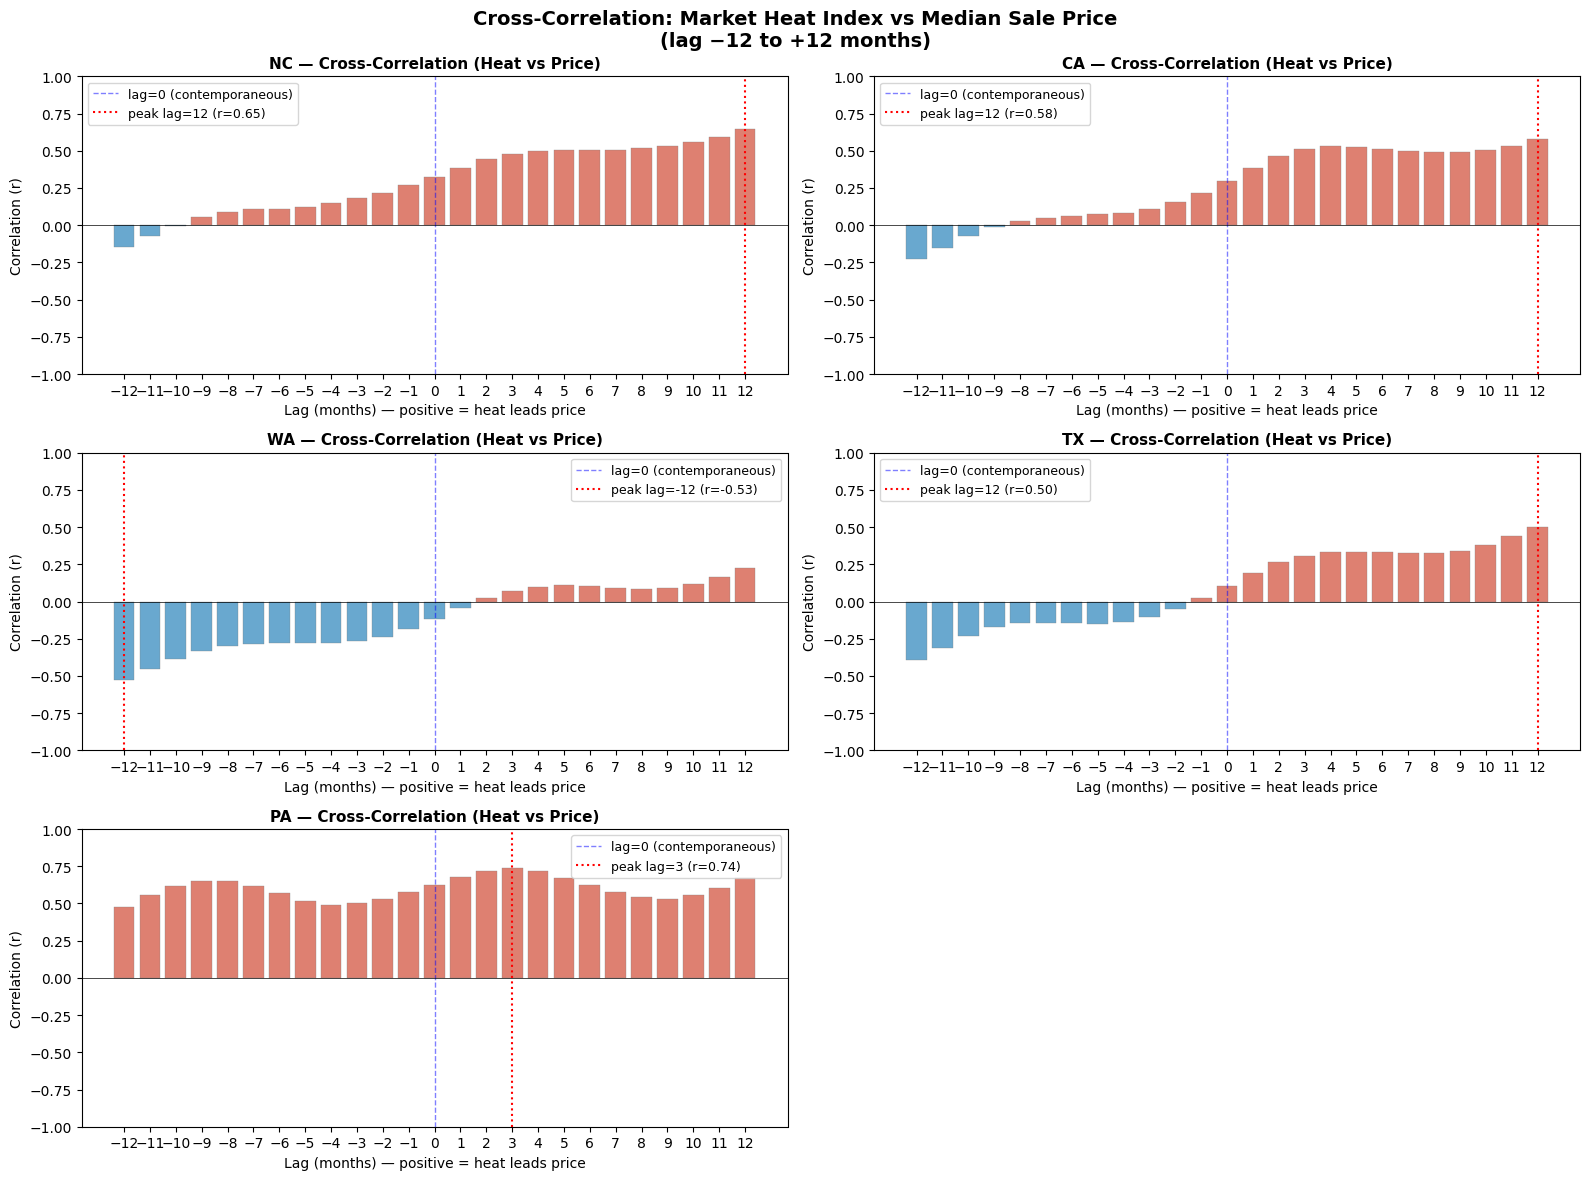


Peak cross-correlation summary:
State     Peak lag (months)     Peak r  Direction
NC                       12       0.645  (heat leads price)
CA                       12       0.579  (heat leads price)
WA                      -12      -0.527  (price leads heat)
TX                       12       0.503  (heat leads price)
PA                        3       0.737  (heat leads price)


In [72]:
lags = range(-12, 13)  # -12 to +12 months

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

peak_lags = {}

for i, abbrev in enumerate(selected_states.keys()):
    ax = axes[i]
    state_df = df_aggregate[df_aggregate['StateName'] == abbrev].dropna().copy()

    price_series = state_df['MedianSalePrice']
    heat_series  = state_df['MarketTemperature']

    # correlation at each lag
    lag_values = []
    for k in lags:
        # positive k: heat leads price
        # negative k: price leads heat
        r = heat_series.shift(k).corr(price_series) #!!! heat index being shifted to left or right to see how it is correlated to the price. 
        lag_values.append(r)

    # the lag with the highest absolute correlation
    best_idx  = int(np.argmax(np.abs(lag_values)))
    best_lag  = list(lags)[best_idx]
    best_corr = lag_values[best_idx]
    peak_lags[abbrev] = (best_lag, best_corr)

    colors = ['#d6604d' if v > 0 else '#4393c3' for v in lag_values]
    ax.bar(lags, lag_values, color=colors, alpha=0.8, edgecolor='grey', linewidth=0.3)

    
    ax.axvline(0, color='blue', linewidth=1, linestyle='--', alpha=0.5, label='lag=0 (contemporaneous)')
    ax.axvline(best_lag, color='red', linewidth=1.5, linestyle=':',
               label=f'peak lag={best_lag} (r={best_corr:.2f})')
    ax.axhline(0, color='black', linewidth=0.5)

    ax.set_title(f'{abbrev} — Cross-Correlation (Heat vs Price)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (months) — positive = heat leads price')
    ax.set_ylabel('Correlation (r)')
    ax.set_xticks(list(lags))
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9)

axes[5].set_visible(False)

plt.suptitle('Cross-Correlation: Market Heat Index vs Median Sale Price\n(lag −12 to +12 months)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\nPeak cross-correlation summary:")
print("=" * 55)
print(f"{'State':<8} {'Peak lag (months)':>18} {'Peak r':>10}  {'Direction'}")
print("=" * 55)
for abbrev, (lag, r) in peak_lags.items():
    direction = 'heat leads price' if lag > 0 else ('price leads heat' if lag < 0 else 'simultaneous')
    print(f"{abbrev:<8} {lag:>18}  {r:>10.3f}  ({direction})")
print("=" * 55)

# 5. Choosing the appropriate model(s) to forecast the data for the specified period for each selected state/house type. Evaluate the model performance using different metrics. Visualise the results with appropriate graphs.

## Stationarity check

Before proceeding with forecasting models we have to check if the time series is stationary or not (Since ARIMA, SARIMA models are built on the assumption that the series is stationary). 

### NOTES

**Stationarity**

A time series is **stationary** when its statistical properties don't change over time, specifically:
1. **Constant mean**
2. **Constant variance**
3. **Constant autocorrelation structure**

We know that median sale price series clearly violates rule number 1. 

Stationarity can be checked by using ADF and KPSS test. 

**ADF**
- H₀: series has a **unit root / is non-stationary**
- p < 0.05 → **stationary**
- p ≥ 0.05 → **non-stationary**

**KPSS**
- H₀: series is **stationary**
- p ≥ 0.05 → **stationary**
- p < 0.05 → **non-stationary**

**What is differencing?**

Differencing can be used to remove trends by calculating ***y′ₜ = yₜ − yₜ₋₁**; if one difference is not enough, a second difference is applied (d=2). The parameter d tells ARIMA/SARIMA how many times to difference the series before fitting the AR/MA structure, so choosing it incorrectly misspecifies the model.

`c` vs `ct`

- **`'c'`**: stationarity around a **constant** (no trend)
- **`'ct'`**: stationarity around a **constant + trend**

Both are useful because a series may be non-stationary under `'c'` but stationary under `'ct'`.


In [73]:
def adfuller_test(data):
    result = adfuller(data, autolag='AIC')
    return result[0], result[1]  # ADF test statistic, p-value

def kpss_test(data, regression='c'):
    stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
    return stat, p_value

results = []

for state, series in states_train.items():  # Run all three tests: ADF (unit-root default), KPSS under 'c', KPSS under 'ct'
    adf_stat, adf_p = adfuller_test(series)
    kpss_c_stat, kpss_c_p = kpss_test(series, regression='c')
    kpss_ct_stat, kpss_ct_p = kpss_test(series, regression='ct')

    adf_stationary = adf_p < 0.05   # Convert each p-value into a plain True/False stationarity verdict.
    kpss_c_stationary = kpss_c_p >= 0.05    #Remember ADF direction is opposite of KPSS

    # combining the two verdicts 
    if not adf_stationary and not kpss_c_stationary:
        case = 'Case 1: Not stationary'
        action = 'Needs differencing (d>=1)'
    elif adf_stationary and kpss_c_stationary:
        case = 'Case 2: Stationary'
        action = 'No differencing needed (d=0)'
    elif not adf_stationary and kpss_c_stationary:
        case = 'Case 3: Trend-stationary'
        action = 'Needs detrending, not differencing'
    else:
        case = 'Case 4: Difference-stationary'
        action = 'Needs differencing (d=1 likely resolves it)'

    results.append({
        'State': state,
        'ADF_stat': round(adf_stat, 3),
        'ADF_p': round(adf_p, 4),
        'KPSS_c_stat': round(kpss_c_stat, 3),
        'KPSS_c_p': round(kpss_c_p, 4),
        'KPSS_ct_p': round(kpss_ct_p, 4),
        'Case': case,
        'Suggested action': action
    })

stationarity_df = pd.DataFrame(results)
display(stationarity_df)

/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range o

,State,ADF_stat,ADF_p,KPSS_c_stat,KPSS_c_p,KPSS_ct_p,Case,Suggested action
0,NC,2.316,0.9990,1.158,0.01,0.01,Case 1: Not stationary,Needs differencing (d>=1)
1,CA,0.960,0.9938,1.774,0.01,0.01,Case 1: Not stationary,Needs differencing (d>=1)
2,WA,2.819,1.0000,1.575,0.01,0.01,Case 1: Not stationary,Needs differencing (d>=1)
3,TX,2.050,0.9987,1.839,0.01,0.01,Case 1: Not stationary,Needs differencing (d>=1)
4,PA,2.583,0.9991,1.687,0.01,0.01,Case 1: Not stationary,Needs differencing (d>=1)


### Differencing and Seasonality check via ACF/PACF

Since now we know that all 5 states are non-stationary at the raw level we have to differentiate, first I should check if d=1 is enough or I should do d=2. <br>
To do this, we have to apply  d=1 then re-run the test part  and see if d=1 was enough, if it is not we have difference again then re-test again. 

In [74]:
states_train_diff1 = {}
results_diff1 = []

for state, series in states_train.items():
    diff1 = series.diff().dropna()
    states_train_diff1[state] = diff1

    adf_stat, adf_p = adfuller_test(diff1)
    kpss_c_stat, kpss_c_p = kpss_test(diff1, regression='c')
    kpss_ct_stat, kpss_ct_p = kpss_test(diff1, regression='ct')

    adf_stationary = adf_p < 0.05
    kpss_c_stationary = kpss_c_p >= 0.05

    if not adf_stationary and not kpss_c_stationary:
        case = 'Case 1: Not stationary'
        action = 'Needs further differencing (d=2)'
    elif adf_stationary and kpss_c_stationary:
        case = 'Case 2: Stationary'
        action = 'd=1 is sufficient'
    elif not adf_stationary and kpss_c_stationary:
        case = 'Case 3: Trend-stationary'
        action = 'Needs detrending, not more differencing'
    else:
        case = 'Case 4: Difference-stationary'
        action = 'd=1 likely sufficient, double-check with ACF'

    results_diff1.append({
        'State': state,
        'ADF_stat': round(adf_stat, 3),
        'ADF_p': round(adf_p, 4),
        'KPSS_c_stat': round(kpss_c_stat, 3),
        'KPSS_c_p': round(kpss_c_p, 4),
        'KPSS_ct_p': round(kpss_ct_p, 4),
        'Case': case,
        'Suggested action': action
    })

stationarity_diff1_df = pd.DataFrame(results_diff1)
display(stationarity_diff1_df)

/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range o

,State,ADF_stat,ADF_p,KPSS_c_stat,KPSS_c_p,KPSS_ct_p,Case,Suggested action
0,NC,-1.130,0.7031,0.811,0.0100,0.1000,Case 1: Not stationary,Needs further differencing (d=2)
1,CA,-4.000,0.0014,0.712,0.0125,0.0901,Case 4: Difference-stationary,"d=1 likely sufficient, double-check with ACF"
2,WA,-0.055,0.9537,0.785,0.0100,0.1000,Case 1: Not stationary,Needs further differencing (d=2)
3,TX,-2.551,0.1036,0.370,0.0902,0.0855,Case 3: Trend-stationary,"Needs detrending, not more differencing"
4,PA,-4.358,0.0004,0.025,0.1000,0.1000,Case 2: Stationary,d=1 is sufficient


**Seasonality check via ACF/PACF**

ACF and PACF tell us the internal correlation structure of the series which is something ADF/KPSS can't see at all, since those only test one thing: is there a trend or not. And catch mistakes that KPSS and ADF can't catch and reveal seasonality.

*From the d=1 stationarity tests, PA, CA, and TX pass, but NC and WA still fail both ADF and KPSS, suggesting they need further differencing. Before differencing again, I checked their ACF/PACF at d=1 anyway: the short-lag correlation already looks reasonably contained, since the tests still say non-stationary, the next step is to try d=2 and re-test.*

*For CA and TX, the picture is different: the correlation drops fast and moves inside the blue band within the first few lags, meaning d=1 already removed the trend. But at lags 12, 24, and 36, the correlation pokes back outside the band, this looks like seasonality, not leftover trend. Since ADF and KPSS only test for trend and can't detect seasonal patterns, this is likely why they show as borderline/non-stationary even though the trend itself is gone. So for CA and TX, I'm not applying a second difference, instead I'll carry this seasonal signal forward into the SARIMA seasonal terms.*

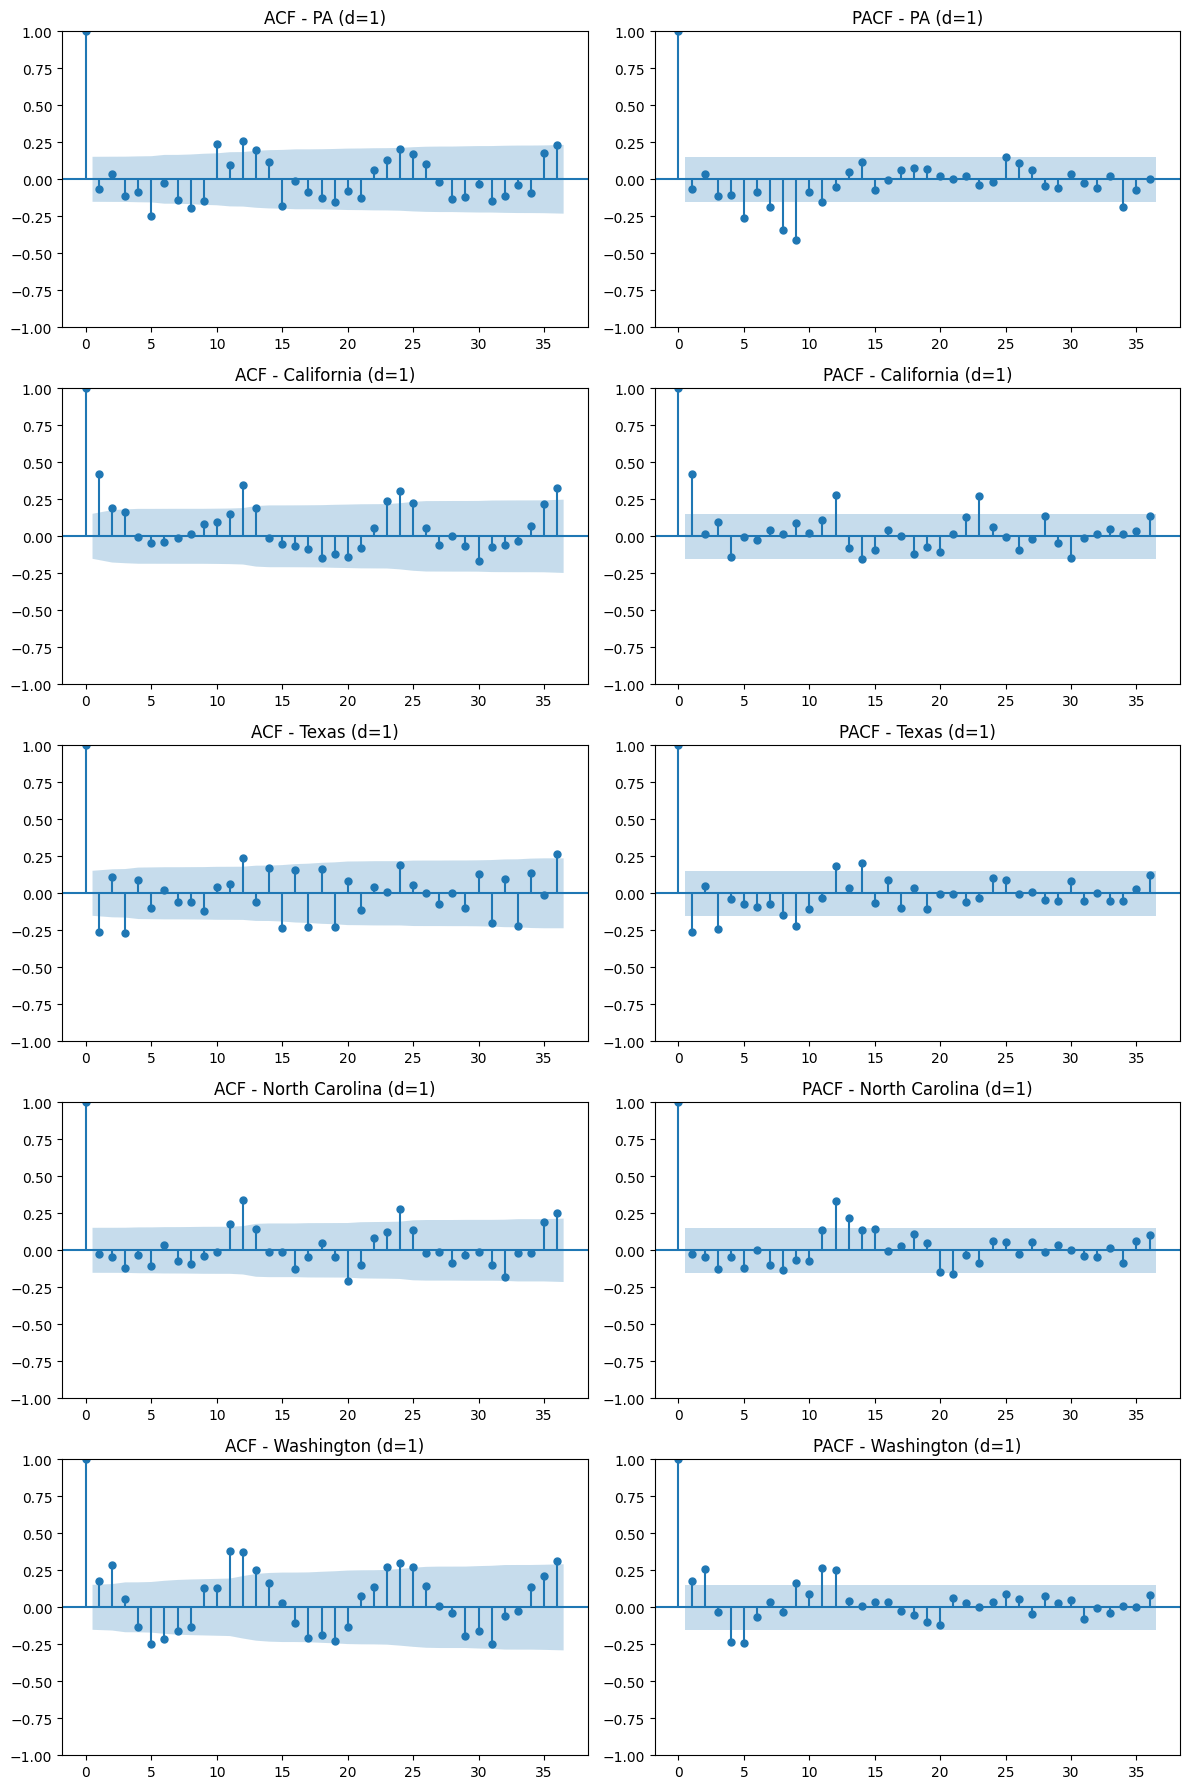

In [75]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))

plot_acf(states_train_diff1['PA'], lags=36, ax=axes[0, 0])
axes[0, 0].set_title('ACF - PA (d=1)')

plot_pacf(states_train_diff1['PA'], lags=36, ax=axes[0, 1])
axes[0, 1].set_title('PACF - PA (d=1)')

plot_acf(states_train_diff1['CA'], lags=36, ax=axes[1, 0])
axes[1, 0].set_title('ACF - California (d=1)')

plot_pacf(states_train_diff1['CA'], lags=36, ax=axes[1, 1])
axes[1, 1].set_title('PACF - California (d=1)')

plot_acf(states_train_diff1['TX'], lags=36, ax=axes[2, 0])
axes[2, 0].set_title('ACF - Texas (d=1)')

plot_pacf(states_train_diff1['TX'], lags=36, ax=axes[2, 1])
axes[2, 1].set_title('PACF - Texas (d=1)')

plot_acf(states_train_diff1['NC'], lags=36, ax=axes[3, 0])
axes[3, 0].set_title('ACF - North Carolina (d=1)')

plot_pacf(states_train_diff1['NC'], lags=36, ax=axes[3, 1])
axes[3, 1].set_title('PACF - North Carolina (d=1)')

plot_acf(states_train_diff1['WA'], lags=36, ax=axes[4, 0])
axes[4, 0].set_title('ACF - Washington (d=1)')

plot_pacf(states_train_diff1['WA'], lags=36, ax=axes[4, 1])
axes[4, 1].set_title('PACF - Washington (d=1)')

plt.tight_layout()
plt.show()

From first differencing we can see that for NC and WA we have to apply second difference and test. For PA is enough just the first difference. But more interesting cases are CA and TX, before applying the second difference I would like to check ACF, after that I will decide if it worth to apply a second difference or not. 

Going back to check CA and TX's d=1 ACF/PACF directly, I found the lag-12/24/36 spikes, a seasonal pattern, not insufficient differencing.

In [76]:
states_train_diff2 = {}
results_diff2 = []

states_needing_diff2 = ['NC', 'WA']

for state in states_needing_diff2:
    diff2 = states_train_diff1[state].diff().dropna()
    states_train_diff2[state] = diff2

    adf_stat, adf_p = adfuller_test(diff2)
    kpss_c_stat, kpss_c_p = kpss_test(diff2, regression='c')
    kpss_ct_stat, kpss_ct_p = kpss_test(diff2, regression='ct')

    adf_stationary = adf_p < 0.05
    kpss_c_stationary = kpss_c_p >= 0.05

    if not adf_stationary and not kpss_c_stationary:
        case = 'Case 1: Not stationary'
        action = 'Needs d=3 (unusual - re-check)'
    elif adf_stationary and kpss_c_stationary:
        case = 'Case 2: Stationary'
        action = 'd=2 is sufficient'
    elif not adf_stationary and kpss_c_stationary:
        case = 'Case 3: Trend-stationary'
        action = 'Needs detrending, not more differencing'
    else:
        case = 'Case 4: Difference-stationary'
        action = 'd=2 likely sufficient, double-check with ACF'

    results_diff2.append({
        'State': state,
        'ADF_stat': round(adf_stat, 3),
        'ADF_p': round(adf_p, 4),
        'KPSS_c_stat': round(kpss_c_stat, 3),
        'KPSS_c_p': round(kpss_c_p, 4),
        'KPSS_ct_p': round(kpss_ct_p, 4),
        'Case': case,
        'Suggested action': action
    })

stationarity_diff2_df = pd.DataFrame(results_diff2)
display(stationarity_diff2_df)

/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct
/tmp/ipykernel_12536/919870022.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(data, regression=regression, nlags='auto') #regression is c or ct


,State,ADF_stat,ADF_p,KPSS_c_stat,KPSS_c_p,KPSS_ct_p,Case,Suggested action
0,NC,-9.535,0.0,0.150,0.1,0.0587,Case 2: Stationary,d=2 is sufficient
1,WA,-10.247,0.0,0.057,0.1,0.1000,Case 2: Stationary,d=2 is sufficient


Sanity check for NC and WA 

At lag=1 we can see  that the line goes to -0.5, this is an overdifferencing signal. So I conclude that d=1 is the correct non-seasonal differencing order for all 5 states. The seasonal structure will be handled by SARIMA's seasonal terms (D, P, Q at lag 12), not by further plain differencing.

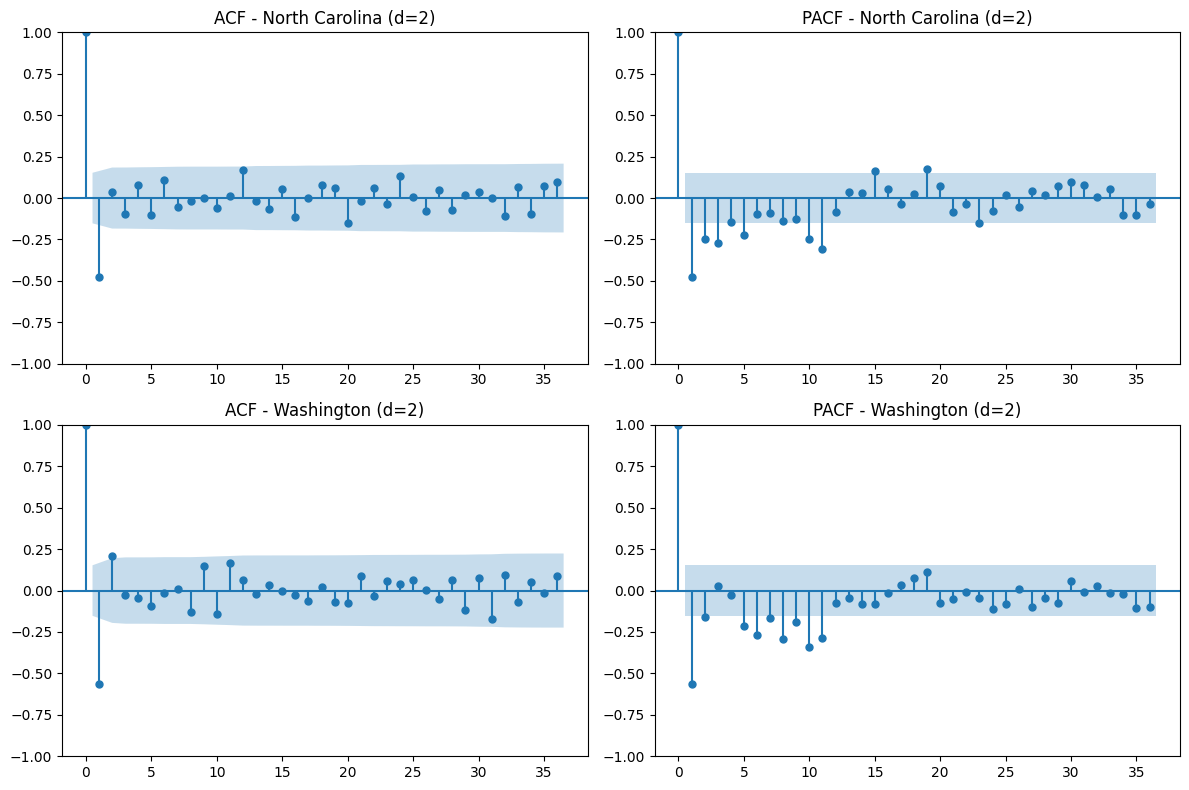

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(states_train_diff2['NC'], lags=36, ax=axes[0, 0])
axes[0, 0].set_title('ACF - North Carolina (d=2)')

plot_pacf(states_train_diff2['NC'], lags=36, ax=axes[0, 1])
axes[0, 1].set_title('PACF - North Carolina (d=2)')

plot_acf(states_train_diff2['WA'], lags=36, ax=axes[1, 0])
axes[1, 0].set_title('ACF - Washington (d=2)')

plot_pacf(states_train_diff2['WA'], lags=36, ax=axes[1, 1])
axes[1, 1].set_title('PACF - Washington (d=2)')

plt.tight_layout()
plt.show()

## Per state: read ACF/PACF, decide on seasonality -> hypothesize SARIMA/ARIMA orders

#### NOTES

***REMEMBER THE ACF/PACF CUTOFF  RULES***

| Pattern | Suggests |
|---|---|
| PACF cuts off sharply after lag k, ACF decays gradually | AR(k) : set p=k |
| ACF cuts off sharply after lag k, PACF decays gradually | MA(k) : set q=k |
| Both decay gradually, no clean cutoff | Mixed ARMA : start small (p=1, q=1) and let AIC decide |
| Significant spike at seasonal lag m, m×2, m×3... | Same logic applied to P/Q, at multiples of 12 instead of 1 |

In [78]:
def significant_lags(series, nlags=36, alpha=0.05, seasonal_only=False):
    """
    Returns which lags have ACF/PACF values outside the confidence band.
    seasonal_only=True restricts the check to multiples of 12 (12, 24, 36).
    """
    acf_vals, acf_confint = acf(series, nlags=nlags, alpha=alpha, fft=False)
    pacf_vals, pacf_confint = pacf(series, nlags=nlags, alpha=alpha)

    # A lag is "significant" if 0 falls outside its confidence interval
    def get_sig_lags(vals, confint):
        sig = []
        for lag in range(1, len(vals)):
            lower, upper = confint[lag]
            if lower > 0 or upper < 0:
                sig.append(lag)
        return sig

    acf_sig = get_sig_lags(acf_vals, acf_confint)
    pacf_sig = get_sig_lags(pacf_vals, pacf_confint)

    if seasonal_only:
        acf_sig = [l for l in acf_sig if l % 12 == 0]
        pacf_sig = [l for l in pacf_sig if l % 12 == 0]

    return acf_sig, pacf_sig

# Run for all 5 states at d=1
diff1_series = {
    'PA': states_train_diff1['PA'],
    'CA': states_train_diff1['CA'],
    'TX': states_train_diff1['TX'],
    'NC': states_train_diff1['NC'],
    'WA': states_train_diff1['WA'],
}

for state, series in diff1_series.items():
    acf_sig, pacf_sig = significant_lags(series, nlags=13)  # short lags: 1-13
    acf_sig_seasonal, pacf_sig_seasonal = significant_lags(series, nlags=36, seasonal_only=True)

    print(f"--- {state} ---")
    print(f"  Significant ACF lags (1-13):  {acf_sig}")
    print(f"  Significant PACF lags (1-13): {pacf_sig}")
    print(f"  Significant seasonal ACF lags (12,24,36):  {acf_sig_seasonal}")
    print(f"  Significant seasonal PACF lags (12,24,36): {pacf_sig_seasonal}")
    print()

--- PA ---
  Significant ACF lags (1-13):  [5, 8, 10, 12, 13]
  Significant PACF lags (1-13): [5, 7, 8, 9, 11]
  Significant seasonal ACF lags (12,24,36):  [12, 36]
  Significant seasonal PACF lags (12,24,36): [36]

--- CA ---
  Significant ACF lags (1-13):  [1, 2, 12]
  Significant PACF lags (1-13): [1, 12]
  Significant seasonal ACF lags (12,24,36):  [12, 24, 36]
  Significant seasonal PACF lags (12,24,36): [12, 36]

--- TX ---
  Significant ACF lags (1-13):  [1, 3, 12]
  Significant PACF lags (1-13): [1, 3, 8, 9, 12]
  Significant seasonal ACF lags (12,24,36):  [12, 36]
  Significant seasonal PACF lags (12,24,36): [12, 36]

--- NC ---
  Significant ACF lags (1-13):  [11, 12]
  Significant PACF lags (1-13): [12, 13]
  Significant seasonal ACF lags (12,24,36):  [12, 24, 36]
  Significant seasonal PACF lags (12,24,36): [12]

--- WA ---
  Significant ACF lags (1-13):  [1, 2, 5, 6, 11, 12, 13]
  Significant PACF lags (1-13): [1, 2, 4, 5, 9, 11, 12]
  Significant seasonal ACF lags (12,24,

#### NOTES

**(p, d, q)(P, D, Q, m)**

- **p** = # non-seasonal AR terms, from PACF cutoff at short lags
- **d** = # regular differencing, already settled (1 for all states)
- **q** = # non-seasonal MA terms, from ACF cutoff at short lags
- **P** = # seasonal AR terms, from PACF cutoff at seasonal lags (12,24,36)
- **D** = # seasonal differencing, 0 when ACF/KPSS didn't require differencing
- **Q** = # seasonal MA terms, from ACF cutoff at seasonal lags
- **m** = season length = 12 (month)

In [79]:
order_hypotheses = {
    'CA': {'order': (1, 1, 0), 'seasonal_order': (1, 0, 0, 12)},
    'NC': {'order': (0, 1, 0), 'seasonal_order': (1, 0, 0, 12)},
    'WA': {'order': (1, 1, 1), 'seasonal_order': (1, 0, 0, 12)},
    'TX': {'order': (1, 1, 1), 'seasonal_order': (0, 0, 1, 12)},
    'PA': {'order': (2, 1, 2), 'seasonal_order': (0, 0, 1, 12)},
}

## Baseline for each state

#### NOTES

**MAE — Mean Absolute Error**

**Formula:**

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

where $y_i$ is the actual value, $\hat{y}_i$ is the forecast, and $n$ is the number of test points.

**How it works:** take the difference between actual and forecast for every month, drop the sign (absolute value, so it doesn't matter if we over- or under-forecast), and average them.

**RMSE — Root Mean Squared Error**

**Formula:**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**How it works:** instead of taking the absolute value of each error, we square it (which also gets rid of the sign, but has a side effect — see below), average those squared errors, then take the square root at the end to bring the number back into the original units.

### Baseline model

This is the simplest forecasting method application, I will use the accuracy of this model as my reference point. 

**Result**

We caan see from the result table that *drift* model wins over all 5 states. 

In [80]:
baseline_results = []

baseline_models = {
    'Mean': HistoricAverage(),
    'Naive': Naive(),
    'Seasonal Naive': SeasonalNaive(season_length=12),
    'Drift': RandomWalkWithDrift()
}

for state in states_train.keys():
    train_series = states_train[state]
    test_series = states_test[state]

    for model_name, model in baseline_models.items():
        fitted_model = model.fit(train_series)
        forecast = fitted_model.predict(len(test_series))

        rmse = root_mean_squared_error(test_series, forecast['mean'])
        mae = mean_absolute_error(test_series, forecast['mean'])

        baseline_results.append({
            'State': state,
            'Model': model_name,
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2)
        })

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)

# Best baseline per state, by RMSE
best_baseline_per_state = baseline_df.loc[baseline_df.groupby('State')['RMSE'].idxmin()]
print("\nBest baseline per state (by RMSE):")
display(best_baseline_per_state)

/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsforecast/utils.py:273: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fcst = {"mean": _repeat_val(val=y[-1], h=h)}
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsforecast/models.py:3682: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = (y[-1] - y[0]) / (y.size - 1)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsforecast/models.py:3683: FutureWarn

,State,Model,RMSE,MAE
0,NC,Mean,113785.93,112119.67
1,NC,Naive,33318.25,28240.41
2,NC,Seasonal Naive,49139.91,45609.82
3,NC,Drift,24598.33,21004.83
4,CA,Mean,262046.97,260933.35
5,CA,Naive,41909.02,36729.99
6,CA,Seasonal Naive,55143.10,50066.93
7,CA,Drift,25097.88,19804.36
8,WA,Mean,218363.34,217213.56
9,WA,Naive,39688.58,34189.96



Best baseline per state (by RMSE):


,State,Model,RMSE,MAE
7,CA,Drift,25097.88,19804.36
3,NC,Drift,24598.33,21004.83
19,PA,Drift,22669.55,18939.56
15,TX,Drift,11052.44,9024.27
11,WA,Drift,20259.35,16931.96


## ETS MODELS

**NOTES**

**ETS in plain terms**

ETS predicts next month's price using three ingredients:

1. **Level** — roughly, "where is the price right now"
2. **Trend** — "is it going up or down, and how fast"
3. **Seasonal** — "does this particular month tend to run higher or lower than usual"

It updates all three every month as new data comes in, then adds them together to forecast.

**What `(A,A,N)` means**

Three letters = three ingredients, in order: **Error, Trend, Seasonal**.

Each letter is either:
- **A** = the ingredient is used, added on (Additive)
- **N** = the ingredient is *not* used (None)
- (there's also **M** = multiplicative, but we're not using that here)

So:

- **`(A,A,N)`** = has a trend, **no seasonality**. "Prices go up/down over time, but no particular month pattern."
- **`(A,Ad,N)`** = has a trend that **fades out** the further you forecast ("d" = damped), **no seasonality**. Same idea, but assumes the trend won't keep going full-speed forever.
- **`(A,A,A)`** = has a trend **and** seasonality. "Prices go up/down over time, AND certain months are typically higher/lower."


Then how to decide when AIC and RMSE don't agree ?
 
                  What is the primary goal?
                                                                
              ┌──────────────┴──────────────┐                        
              ▼                             ▼                   
     [ Pure Prediction ]          [ Explanation & Inference ]     
              │                             │
    Choose the RMSE winner         Choose the AIC winner
   (Validate with Holdout/CV)     (Prioritize simpler equations)




We don't know in advance whether each state actually has real seasonality or a trend that's slowing down, so instead of guessing, we fit all three versions per state and let AIC (fit quality) tell us which one the data actually supports.

**AIC and RMSE disagreement**<br>
AIC and RMSE only agree when the test period behaves similarly to training. Our test window is exactly the post-2022 rate-hike period, when housing markets cooled or flattened, a real behavioral shift from most of the training window. So the disagreement is expected. 

**Conclusion:**

- **NC**: AIC and RMSE **agree** : `A,A,N` (no seasonal) wins both. Clean, confident pick.
- **TX**: AIC and RMSE agree : `A,A,A` (seasonal) wins both, matches our earlier hunch this state had *some* seasonal signal.
- **PA**: AIC and RMSE **disagree** — AIC prefers the seasonal version, but RMSE clearly favors `A,A,N` (11,003 vs. 17,329). Interesting twist: this actually **contradicts** the small seasonal hint from our baseline stage (where Seasonal Naive edged out Naive for PA), worth noting that tension explicitly rather than picking whichever confirms the earlier hunch.
- **CA**: AIC prefers damped trend, RMSE prefers plain `A,A,N`, but both are bad relative to baseline anyway, so this disagreement barely matters; the real story is ETS underperforming here at all.
- **WA**: AIC and RMSE disagree (seasonal vs. damped), and again both options are far worse than baseline, same story as CA.


For our case I would prefer to go ahead  with RMSE winner. 

In [81]:
ets_results = []
ets_fitted_models = {}

for state in states_train.keys():
    train_series = states_train[state]
    test_series = states_test[state]
    h = len(test_series)

    candidates = {
        'ETS(A,A,N) - no seasonal': dict(error='add', trend='add', damped_trend=False, seasonal=None),
        'ETS(A,Ad,N) - damped trend': dict(error='add', trend='add', damped_trend=True, seasonal=None),
        'ETS(A,A,A) - seasonal': dict(error='add', trend='add', damped_trend=False, seasonal='add', seasonal_periods=12),
    }

    for name, params in candidates.items():
        try:
            model = ETSModel(train_series, **params)
            fit = model.fit(disp=False)

            forecast = fit.forecast(h)
            rmse = root_mean_squared_error(test_series, forecast)
            mae = mean_absolute_error(test_series, forecast)

            ets_results.append({
                'State': state,
                'Model': name,
                'AIC': round(fit.aic, 1),
                'RMSE': round(rmse, 2),
                'MAE': round(mae, 2)
            })
            ets_fitted_models[(state, name)] = fit

        except Exception as e:
            print(f"{state} - {name} failed: {e}")

ets_df = pd.DataFrame(ets_results)
display(ets_df)

# Best ETS per state by AIC (fit quality) vs by RMSE (forecast accuracy) 
best_ets_by_aic = ets_df.loc[ets_df.groupby('State')['AIC'].idxmin()]
best_ets_by_rmse = ets_df.loc[ets_df.groupby('State')['RMSE'].idxmin()]

print("Best ETS per state by AIC:")
display(best_ets_by_aic)
print("\nBest ETS per state by RMSE:")
display(best_ets_by_rmse)

/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: Valu

,State,Model,AIC,RMSE,MAE
0,NC,"ETS(A,A,N) - no seasonal",3380.0,10717.56,8965.15
1,NC,"ETS(A,Ad,N) - damped trend",3381.1,29983.75,25367.44
2,NC,"ETS(A,A,A) - seasonal",3383.6,11651.73,9394.86
3,CA,"ETS(A,A,N) - no seasonal",3445.8,35950.50,31515.81
4,CA,"ETS(A,Ad,N) - damped trend",3433.0,45302.23,40004.16
5,CA,"ETS(A,A,A) - seasonal",3496.6,62299.31,56347.22
6,WA,"ETS(A,A,N) - no seasonal",3394.1,39894.93,34489.03
7,WA,"ETS(A,Ad,N) - damped trend",3371.2,39849.82,34369.03
8,WA,"ETS(A,A,A) - seasonal",3347.5,72401.50,62895.30
9,TX,"ETS(A,A,N) - no seasonal",3411.7,11475.49,9048.53


Best ETS per state by AIC:


,State,Model,AIC,RMSE,MAE
4,CA,"ETS(A,Ad,N) - damped trend",3433.0,45302.23,40004.16
0,NC,"ETS(A,A,N) - no seasonal",3380.0,10717.56,8965.15
14,PA,"ETS(A,A,A) - seasonal",3375.6,17328.58,14609.63
11,TX,"ETS(A,A,A) - seasonal",3393.1,10976.36,8715.42
8,WA,"ETS(A,A,A) - seasonal",3347.5,72401.50,62895.30



Best ETS per state by RMSE:


,State,Model,AIC,RMSE,MAE
3,CA,"ETS(A,A,N) - no seasonal",3445.8,35950.50,31515.81
0,NC,"ETS(A,A,N) - no seasonal",3380.0,10717.56,8965.15
12,PA,"ETS(A,A,N) - no seasonal",3450.7,11002.78,9354.78
11,TX,"ETS(A,A,A) - seasonal",3393.1,10976.36,8715.42
7,WA,"ETS(A,Ad,N) - damped trend",3371.2,39849.82,34369.03


### Comparison: Best baseline per state (by RMSE) and Best ETS per state by RMSE:

*For NC, PA, and TX, ETS gives a clear improvement over the Drift baseline — the model is capturing real patterns in the data, not just adding unnecessary complexity.*

*For CA and WA, however, Drift is still the best-performing model at this stage.*

In [82]:
display(best_baseline_per_state, best_ets_by_rmse)

,State,Model,RMSE,MAE
7,CA,Drift,25097.88,19804.36
3,NC,Drift,24598.33,21004.83
19,PA,Drift,22669.55,18939.56
15,TX,Drift,11052.44,9024.27
11,WA,Drift,20259.35,16931.96


,State,Model,AIC,RMSE,MAE
3,CA,"ETS(A,A,N) - no seasonal",3445.8,35950.50,31515.81
0,NC,"ETS(A,A,N) - no seasonal",3380.0,10717.56,8965.15
12,PA,"ETS(A,A,N) - no seasonal",3450.7,11002.78,9354.78
11,TX,"ETS(A,A,A) - seasonal",3393.1,10976.36,8715.42
7,WA,"ETS(A,Ad,N) - damped trend",3371.2,39849.82,34369.03


## SARIMA per state (manual + auto_arima)

**RESULTS:**

## Manual vs. Auto 

| State | Manual | Auto | Winner |
|---|---|---|---|
| NC | AIC 3086.2, RMSE 20,891 | AIC 3350.5, RMSE 31,903 | **Manual wins clearly**, (0,1,0)(1,0,0,12) hypothesis was right |
| CA | AIC 3111.4, RMSE 22,694 | AIC 3432.6, RMSE 25,098 | **Manual wins**, (1,1,0)(1,0,0,12) beats auto |
| WA | AIC 3060.5, RMSE 32,617 | AIC 3343.9, RMSE 17,908 | **Auto wins decisively**, (1,1,1)(1,0,0,12) had lower AIC but much worse forecast |
| TX | AIC 3100.9, RMSE 14,916 | AIC 3388.5, RMSE 11,672 | **Auto wins on RMSE** |
| PA | AIC 3037.7, RMSE 29,364 | AIC 3351.4, RMSE 24,185 | **Auto wins on RMSE** |

In [83]:
sarima_results = []
sarima_fitted_models = {}

for state in states_train.keys():
    train_series = states_train[state]
    test_series = states_test[state]
    h = len(test_series)

    # --- Manual model, from ACF/PACF hypothesis ---
    manual_spec = order_hypotheses[state]
    manual_model = SARIMAX(
        train_series,
        order=manual_spec['order'],
        seasonal_order=manual_spec['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    manual_fit = manual_model.fit(disp=False)
    manual_forecast = manual_fit.get_forecast(h).predicted_mean

    sarima_results.append({
        'State': state,
        'Model': f"Manual {manual_spec['order']}{manual_spec['seasonal_order']}",
        'AIC': round(manual_fit.aic, 1),
        'RMSE': round(root_mean_squared_error(test_series, manual_forecast), 2),
        'MAE': round(mean_absolute_error(test_series, manual_forecast), 2)
    })
    sarima_fitted_models[(state, 'manual')] = manual_fit

    # --- auto_arima cross-check ---
    auto_model = pm.auto_arima(
        train_series,
        seasonal=True, m=12,
        d=1,                    # we already established this
        start_p=0, start_q=0, max_p=3, max_q=3,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )
    auto_forecast = auto_model.predict(h)

    sarima_results.append({
        'State': state,
        'Model': f"Auto {auto_model.order}{auto_model.seasonal_order}",
        'AIC': round(auto_model.aic(), 1),
        'RMSE': round(root_mean_squared_error(test_series, auto_forecast), 2),
        'MAE': round(mean_absolute_error(test_series, auto_forecast), 2)
    })
    sarima_fitted_models[(state, 'auto')] = auto_model

sarima_df = pd.DataFrame(sarima_results)
display(sarima_df)

best_sarima_by_rmse = sarima_df.loc[sarima_df.groupby('State')['RMSE'].idxmin()]
print("Best SARIMA per state (by RMSE):")
display(best_sarima_by_rmse)

/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: Valu

,State,Model,AIC,RMSE,MAE
0,NC,"Manual (0, 1, 0)(1, 0, 0, 12)",3086.2,20890.82,17418.29
1,NC,"Auto (0, 1, 1)(1, 0, 0, 12)",3350.5,31903.30,26945.65
2,CA,"Manual (1, 1, 0)(1, 0, 0, 12)",3111.4,22693.69,18063.70
3,CA,"Auto (0, 1, 0)(0, 0, 0, 12)",3432.6,25097.88,19804.36
4,WA,"Manual (1, 1, 1)(1, 0, 0, 12)",3060.5,32617.12,28413.04
5,WA,"Auto (0, 1, 0)(1, 0, 0, 12)",3343.9,17907.69,14410.95
6,TX,"Manual (1, 1, 1)(0, 0, 1, 12)",3100.9,14916.49,11706.23
7,TX,"Auto (2, 1, 2)(1, 0, 0, 12)",3388.5,11672.46,9797.35
8,PA,"Manual (2, 1, 2)(0, 0, 1, 12)",3037.7,29364.41,25088.68
9,PA,"Auto (1, 1, 1)(1, 0, 1, 12)",3351.4,24185.34,20279.98


Best SARIMA per state (by RMSE):


,State,Model,AIC,RMSE,MAE
2,CA,"Manual (1, 1, 0)(1, 0, 0, 12)",3111.4,22693.69,18063.70
0,NC,"Manual (0, 1, 0)(1, 0, 0, 12)",3086.2,20890.82,17418.29
9,PA,"Auto (1, 1, 1)(1, 0, 1, 12)",3351.4,24185.34,20279.98
7,TX,"Auto (2, 1, 2)(1, 0, 0, 12)",3388.5,11672.46,9797.35
5,WA,"Auto (0, 1, 0)(1, 0, 0, 12)",3343.9,17907.69,14410.95


### BASELINE, ETS AND SARIMA MODELS COMPARISON


| State | Drift RMSE | Best ETS RMSE | **Best SARIMA RMSE** | SARIMA beats Drift? |
|---|---|---|---|---|
| CA | 25,098 | 35,951 | **22,694** | **Yes** |
| NC | 24,598 | 10,718 | 20,891 | Yes, but ETS still best overall |
| PA | 22,670 | 11,003 | 24,185 | No, ETS is still best |
| TX | 11,052 | 10,976 | 11,672 | No, ETS is still slightly better |
| WA | 20,259 | 39,850 | **17,908** | **Yes** |

## Current best model per state, across everything so far

| State | Best model | RMSE |
|---|---|---|
| CA | SARIMA Manual (1,1,0)(1,0,0,12) | 22,694 |
| NC | ETS (A,A,N) | 10,718 |
| PA | ETS (A,A,N) | 11,003 |
| TX | ETS (A,A,A) | 10,976 |
| WA | SARIMA Auto (0,1,0)(1,0,0,12) | 17,908 |

So, we notice that **no single model family wins everywhere**, different states needed different tools.

In [84]:
# display(best_baseline_per_state, best_ets_by_rmse, best_sarima_by_rmse)

## RESIDUAL DIAGNOSTICS FOR THE CURRENT BEST MODELS

**NOTES**
The three tests: 
- **Ljung-Box**: tests whether there's leftover autocorrelation in the residuals. Null hypothesis = "no autocorrelation left" (good). p ≥ 0.05 → model captured the structure well. p < 0.05 → something's still there the model missed.
- **Jarque-Bera:** tests whether residuals are normally distributed. Null = "residuals are normal." p ≥ 0.05 is good (matches the assumption most of these models rely on).
- **Durbin-Watson:** a simpler, quicker check specifically for lag-1 autocorrelation. Value near 2 = good (no autocorrelation); far from 2 (toward 0 or 4) = a problem.

---
**Results**

**NC**: passes all checks, clean residuals, no issues.

**TX**: passes all checks, clean residuals, no issues.

**CA**: no autocorrelation left, but residuals aren't perfectly normal (likely due to extreme 2008 crash values), minor limitation, doesn't affect the forecast itself.

**WA**: same as CA, clean of autocorrelation, but non-normal residuals from the same 2008 crash effect.

**PA**: fails Ljung-Box, real autocorrelation remains, matching the lag-5to9 pattern found earlier in PA's ACF/PACF. (See below) I tried also an alternative SARIMA (2,1,2)(0,0,1,12) which fixes this but forecasts worse, so this is a real trade-off between statistical fit and accuracy.

In [85]:
# Map each state to its actual winning model
best_models = {
    'NC': ('ets', ets_fitted_models[('NC', 'ETS(A,A,N) - no seasonal')]),
    'PA': ('ets', ets_fitted_models[('PA', 'ETS(A,A,N) - no seasonal')]),
    'TX': ('ets', ets_fitted_models[('TX', 'ETS(A,A,A) - seasonal')]),
    'CA': ('sarima', sarima_fitted_models[('CA', 'manual')]),
    'WA': ('sarima', sarima_fitted_models[('WA', 'auto')]),
}

def get_residuals(model_type, fit):
    """Handles the 3 different residual formats: ETS, statsmodels SARIMAX, pmdarima auto_arima."""
    if model_type == 'ets':
        return pd.Series(fit.resid).dropna()
    else:  # sarima
        if isinstance(fit, pm.arima.ARIMA):
            # pmdarima result — resid is a METHOD, must be called
            return pd.Series(fit.resid()).dropna()
        else:
            # statsmodels SARIMAX result — resid is a plain attribute
            return pd.Series(fit.resid).dropna()

# --- 1. Diagnostics table ---
diagnostic_results = []

for state, (model_type, fit) in best_models.items():
    resid = get_residuals(model_type, fit)

    lb_result = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p = lb_result['lb_pvalue'].values[0]

    jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    dw_stat = durbin_watson(resid)

    diagnostic_results.append({
        'State': state,
        'Model': model_type.upper(),
        'Ljung-Box p': round(lb_p, 4),
        'Ljung-Box OK?': 'Yes' if lb_p >= 0.05 else 'No - autocorrelation left',
        'Jarque-Bera p': round(jb_p, 4),
        'JB OK?': 'Yes' if jb_p >= 0.05 else 'No - not normal',
        'Durbin-Watson': round(dw_stat, 3)
    })

diagnostics_df = pd.DataFrame(diagnostic_results)
display(diagnostics_df)



,State,Model,Ljung-Box p,Ljung-Box OK?,Jarque-Bera p,JB OK?,Durbin-Watson
0,NC,ETS,0.1293,Yes,0.1126,Yes,1.972
1,PA,ETS,0.0000,No - autocorrelation left,0.6202,Yes,0.716
2,TX,ETS,0.3739,Yes,0.4863,Yes,1.875
3,CA,SARIMA,0.8503,Yes,0.0000,No - not normal,1.464
4,WA,SARIMA,0.9954,Yes,0.0000,No - not normal,1.137


Visual check

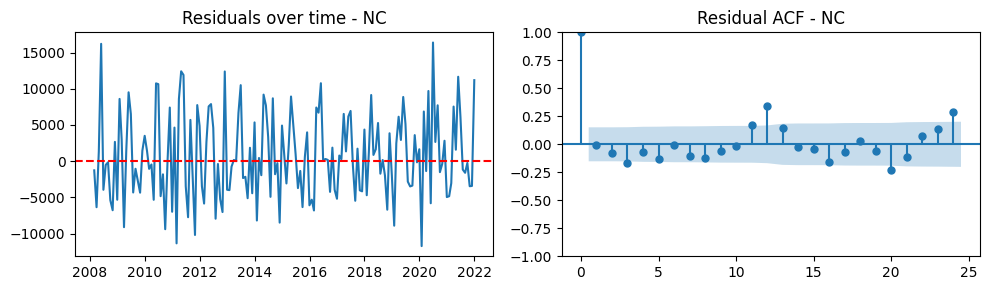

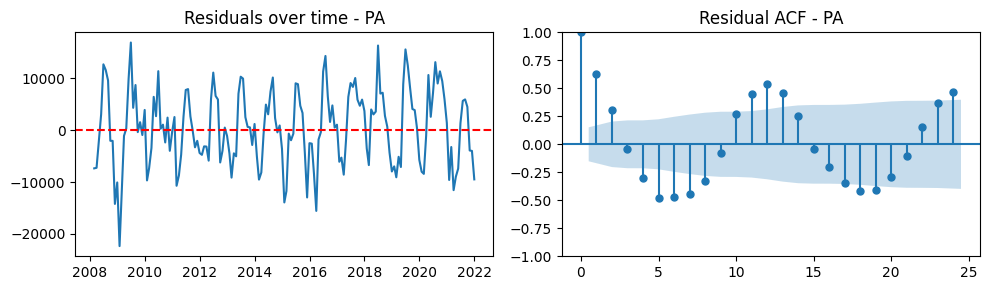

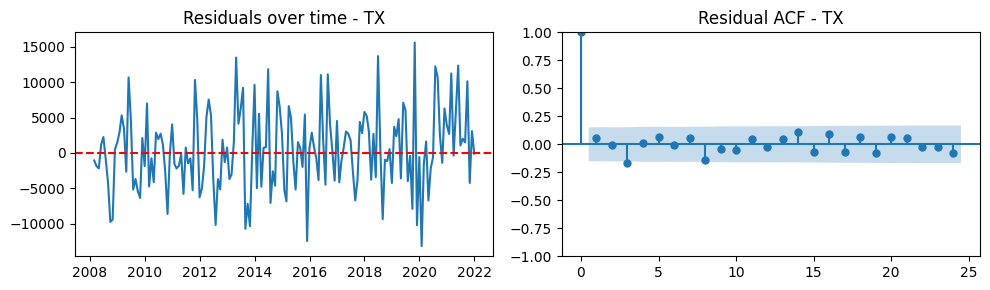

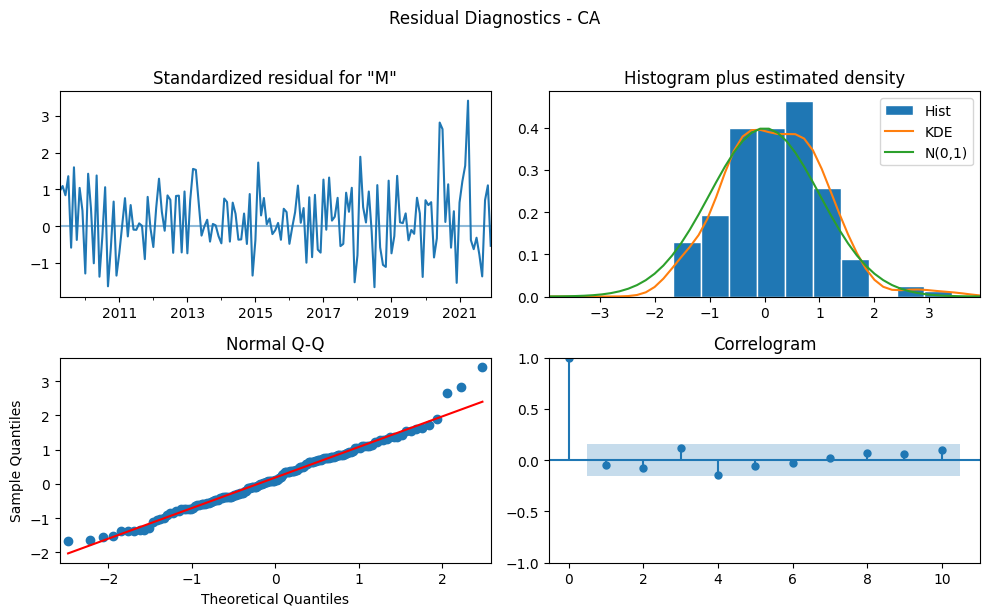

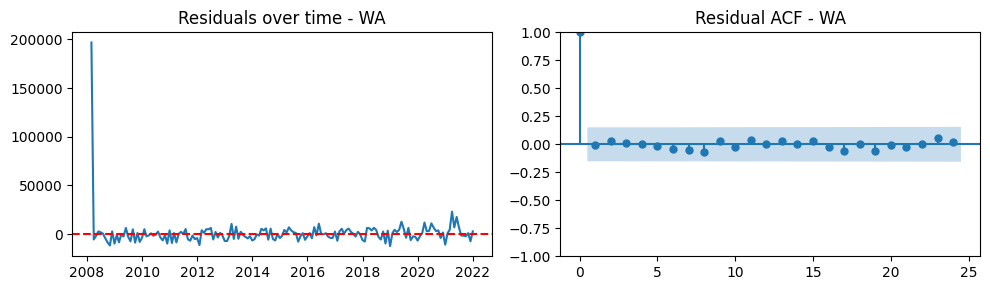

In [86]:
for state, (model_type, fit) in best_models.items():
    if model_type == 'sarima' and hasattr(fit, 'plot_diagnostics') and not isinstance(fit, pm.arima.ARIMA):
        # statsmodels SARIMAX has a built-in 4-panel diagnostic plot
        fig = fit.plot_diagnostics(figsize=(10, 6))
        fig.suptitle(f'Residual Diagnostics - {state}', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        # ETS and pmdarima auto_arima: build the equivalent manually
        resid = get_residuals(model_type, fit)
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        axes[0].plot(resid)
        axes[0].axhline(0, color='red', linestyle='--')
        axes[0].set_title(f'Residuals over time - {state}')
        plot_acf(resid, lags=24, ax=axes[1])
        axes[1].set_title(f'Residual ACF - {state}')
        plt.tight_layout()
        plt.show()

***ETS achieves better forecast accuracy for PA, but its residuals show significant leftover autocorrelation (Ljung-Box p<0.001), suggesting it may not be fully capturing PA's underlying dynamics. SARIMA(2,1,2)(0,0,1,12), informed by the distinct lag-5-9 correlation structure found before, resolves this (Ljung-Box p=0.72) at the cost of forecast accuracy on this test window.***

,Model,Ljung-Box p,Ljung-Box OK?,Jarque-Bera p,JB OK?,Durbin-Watson
0,"PA Manual (2,1,2)(0,0,1,12)",0.7166,Yes,0.0,No - not normal,1.242
1,"PA Auto (1,1,1)(0,1,1,12)",0.8365,Yes,0.0,No - not normal,1.338


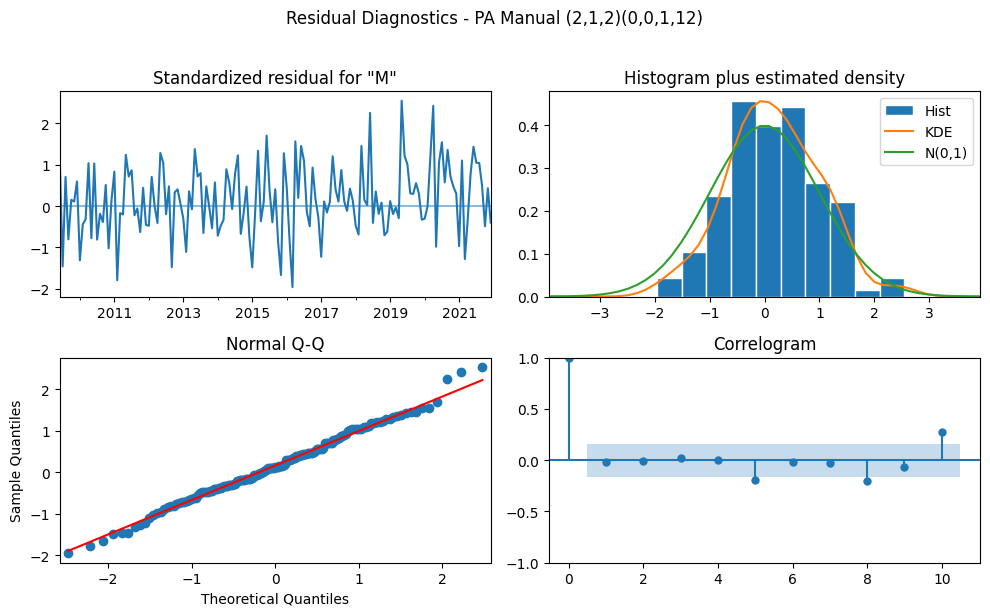

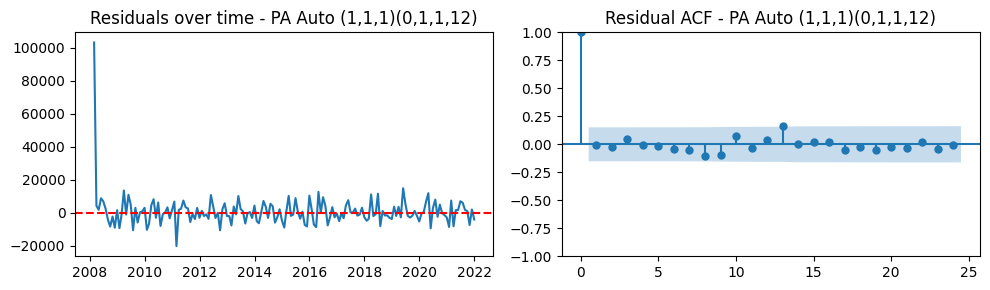

In [87]:
pa_sarima_candidates = {
    'PA Manual (2,1,2)(0,0,1,12)': sarima_fitted_models[('PA', 'manual')],
    'PA Auto (1,1,1)(0,1,1,12)': sarima_fitted_models[('PA', 'auto')],
}

pa_diagnostic_results = []

for label, fit in pa_sarima_candidates.items():
    resid = get_residuals('sarima', fit)

    lb_result = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]

    jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    dw_stat = durbin_watson(resid)

    pa_diagnostic_results.append({
        'Model': label,
        'Ljung-Box p': round(lb_p, 4),
        'Ljung-Box OK?': 'Yes' if lb_p >= 0.05 else 'No - autocorrelation left',
        'Jarque-Bera p': round(jb_p, 4),
        'JB OK?': 'Yes' if jb_p >= 0.05 else 'No - not normal',
        'Durbin-Watson': round(dw_stat, 3)
    })

pa_diagnostics_df = pd.DataFrame(pa_diagnostic_results)
display(pa_diagnostics_df)

# Visual check for both
for label, fit in pa_sarima_candidates.items():
    if hasattr(fit, 'plot_diagnostics') and not isinstance(fit, pm.arima.ARIMA):
        fig = fit.plot_diagnostics(figsize=(10, 6))
        fig.suptitle(f'Residual Diagnostics - {label}', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        resid = get_residuals('sarima', fit)
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        axes[0].plot(resid)
        axes[0].axhline(0, color='red', linestyle='--')
        axes[0].set_title(f'Residuals over time - {label}')
        plot_acf(resid, lags=24, ax=axes[1])
        axes[1].set_title(f'Residual ACF - {label}')
        plt.tight_layout()
        plt.show()

# METRICS TABLE

We can conclude that the no single model wins across all states. 

## Final model per state

| State | Winning model | RMSE | MAPE |
|---|---|---|---|
| CA | SARIMA Manual (1,1,0)(1,0,0,12) | 22,694 | 2.98% |
| NC | ETS(A,A,N) | 10,718 | 3.28% |
| PA | ETS(A,A,N) | 11,003 | 5.20% |
| TX | ETS(A,A,A) | 10,976 | 3.28% |
| WA | SARIMA Auto (0,1,0)(1,0,0,12) | 17,908 | 3.21% |

In [88]:
final_comparison = []

# --- Baselines (Drift only, since that's the winner everywhere) ---
for state in states_train.keys():
    row = baseline_df[(baseline_df['State'] == state) & (baseline_df['Model'] == 'Drift')].iloc[0]
    final_comparison.append({
        'State': state, 'Model': 'Baseline (Drift)',
        'RMSE': row['RMSE'], 'MAE': row['MAE'], 'MAPE (%)': None  # computed separately below
    })

# --- Best ETS per state (by RMSE) ---
for _, row in best_ets_by_rmse.iterrows():
    final_comparison.append({
        'State': row['State'], 'Model': f"ETS - {row['Model']}",
        'RMSE': row['RMSE'], 'MAE': row['MAE'], 'MAPE (%)': None
    })

# --- Best SARIMA per state (by RMSE) ---
for _, row in best_sarima_by_rmse.iterrows():
    final_comparison.append({
        'State': row['State'], 'Model': f"SARIMA - {row['Model']}",
        'RMSE': row['RMSE'], 'MAE': row['MAE'], 'MAPE (%)': None
    })

final_df = pd.DataFrame(final_comparison)

# MAPE for each row 
mape_lookup = {}

for state in states_train.keys():
    test_series = states_test[state]

    # Drift baseline
    drift_fit = RandomWalkWithDrift().fit(states_train[state])
    drift_forecast = drift_fit.predict(len(test_series))['mean']
    mape_lookup[(state, 'Baseline (Drift)')] = mean_absolute_percentage_error(test_series, drift_forecast) * 100

    # Best ETS
    best_ets_name = best_ets_by_rmse[best_ets_by_rmse['State']==state]['Model'].values[0]
    ets_fit = ets_fitted_models[(state, best_ets_name)]
    ets_forecast = ets_fit.forecast(len(test_series))
    mape_lookup[(state, f'ETS - {best_ets_name}')] = mean_absolute_percentage_error(test_series, ets_forecast) * 100

    # Best SARIMA
    best_sarima_name = best_sarima_by_rmse[best_sarima_by_rmse['State']==state]['Model'].values[0]
    model_key = 'manual' if 'Manual' in best_sarima_name else 'auto'
    sarima_fit = sarima_fitted_models[(state, model_key)]
    if isinstance(sarima_fit, pm.arima.ARIMA):
        sarima_forecast = sarima_fit.predict(len(test_series))
    else:
        sarima_forecast = sarima_fit.get_forecast(len(test_series)).predicted_mean
    mape_lookup[(state, f'SARIMA - {best_sarima_name}')] = mean_absolute_percentage_error(test_series, sarima_forecast) * 100

# Fill in the MAPE column
final_df['MAPE (%)'] = final_df.apply(lambda r: round(mape_lookup.get((r['State'], r['Model']), float('nan')), 2), axis=1)
final_df['RMSE'] = final_df['RMSE'].round(2)
final_df['MAE'] = final_df['MAE'].round(2)

# Mark the overall winner per state (by RMSE, your primary criterion throughout)
final_df['Best in state?'] = final_df.groupby('State')['RMSE'].transform(lambda x: x == x.min())

final_df = final_df.sort_values(['State', 'RMSE']).reset_index(drop=True)
display(final_df)

/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsforecast/models.py:3682: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = (y[-1] - y[0]) / (y.size - 1)
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsforecast/models.py:3683: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean = slope * (1 + np.arange(h, dtype=y.dtype)) + y[-1]
/home/hatice/Desktop/DataScienceUniVR/statistical models/PropertyPriceForecasting/.venv/lib/python3.10/site-packages/statsforecast/models.py:36

,State,Model,RMSE,MAE,MAPE (%),Best in state?
0,CA,"SARIMA - Manual (1, 1, 0)(1, 0, 0, 12)",22693.69,18063.70,2.98,True
1,CA,Baseline (Drift),25097.88,19804.36,3.23,False
2,CA,"ETS - ETS(A,A,N) - no seasonal",35950.50,31515.81,5.19,False
3,NC,"ETS - ETS(A,A,N) - no seasonal",10717.56,8965.15,3.28,True
4,NC,"SARIMA - Manual (0, 1, 0)(1, 0, 0, 12)",20890.82,17418.29,6.10,False
5,NC,Baseline (Drift),24598.33,21004.83,7.36,False
6,PA,"ETS - ETS(A,A,N) - no seasonal",11002.78,9354.78,5.20,True
7,PA,Baseline (Drift),22669.55,18939.56,9.84,False
8,PA,"SARIMA - Auto (1, 1, 1)(1, 0, 1, 12)",24185.34,20279.98,10.53,False
9,TX,"ETS - ETS(A,A,A) - seasonal",10976.36,8715.42,3.28,True


# PLOTS

**CONCLUSION**

**CA**: Forecast tracks the test period's flattening trend well, and all actuals stay within the CI band, SARIMA handled the post-2022 slowdown appropriately. We can also see the 2.98% MAPE result -> this is the best performing model.

**NC**: Forecast line closely tracks the upward trend in the test data; actuals mostly stay close to the forecast line, only drifting near the CI edge toward the end. Captures the overall trend with relatively small forecasting errors (MAPE 3.28%).

**PA**: The forecast line is smoother than the actual data, which visibly oscillates around it in a repeating pattern the model doesn't fully capture. Looking at the MAPE results, 5.2%, we can say that its the models with weakest performance.

**TX**: Forecast tracks the general level of actuals reasonably well but misses some of the sharper short-term fluctuations. (MAPE 3.28%)

**WA**: Looking also at MAPE 3.21% we can say that this model accurately captures the long-term upward trend but missing some short-term volatility. 


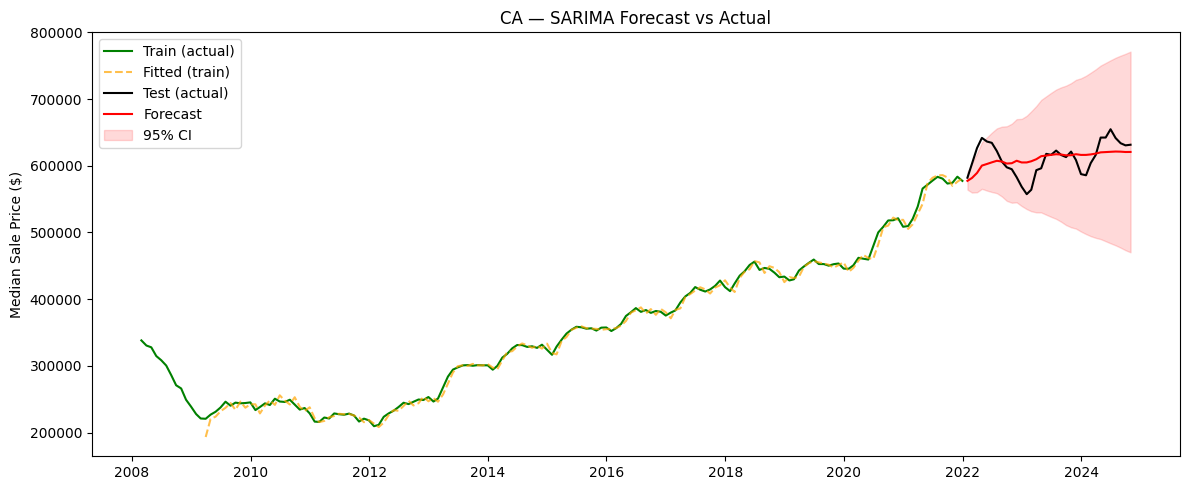

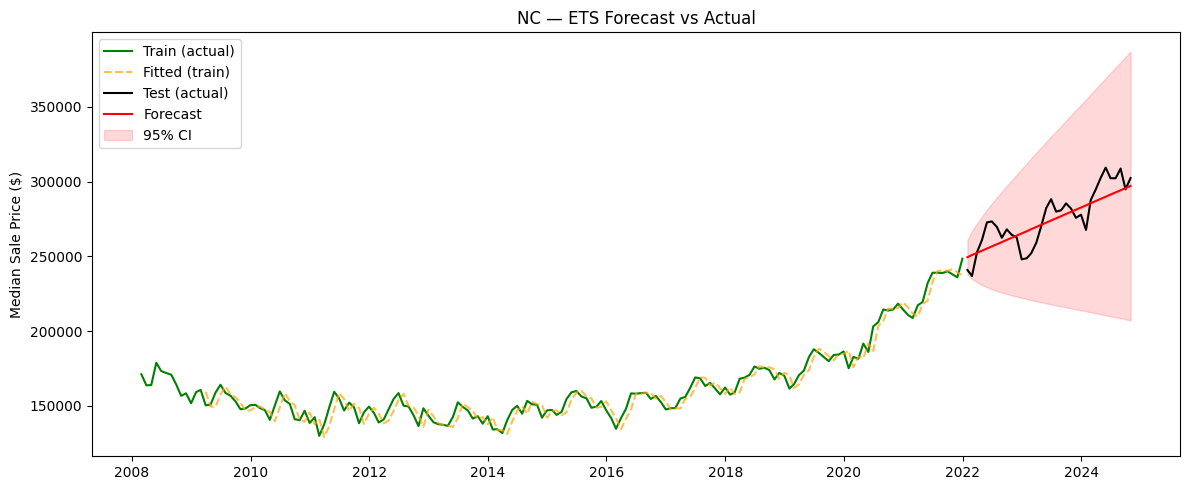

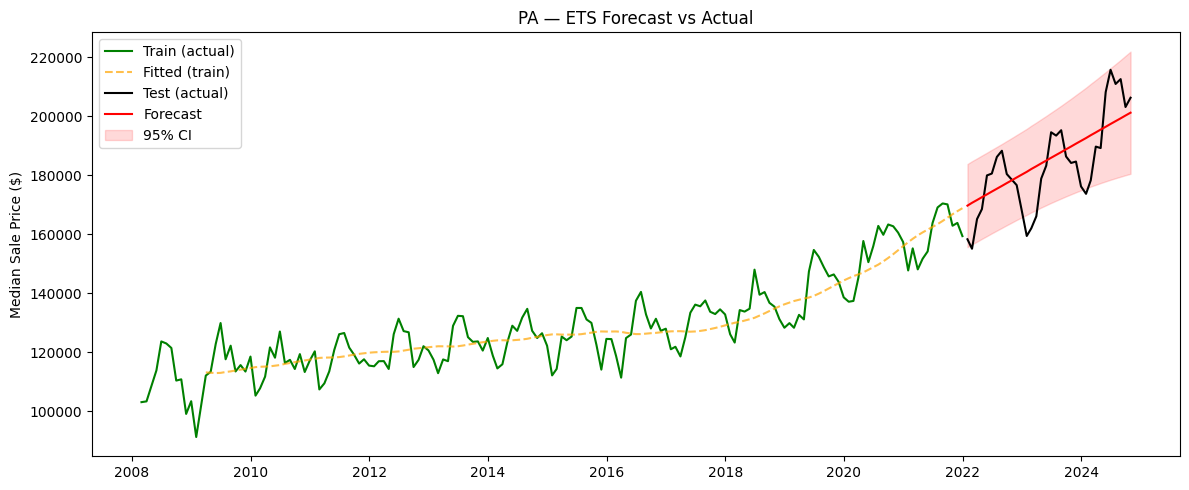

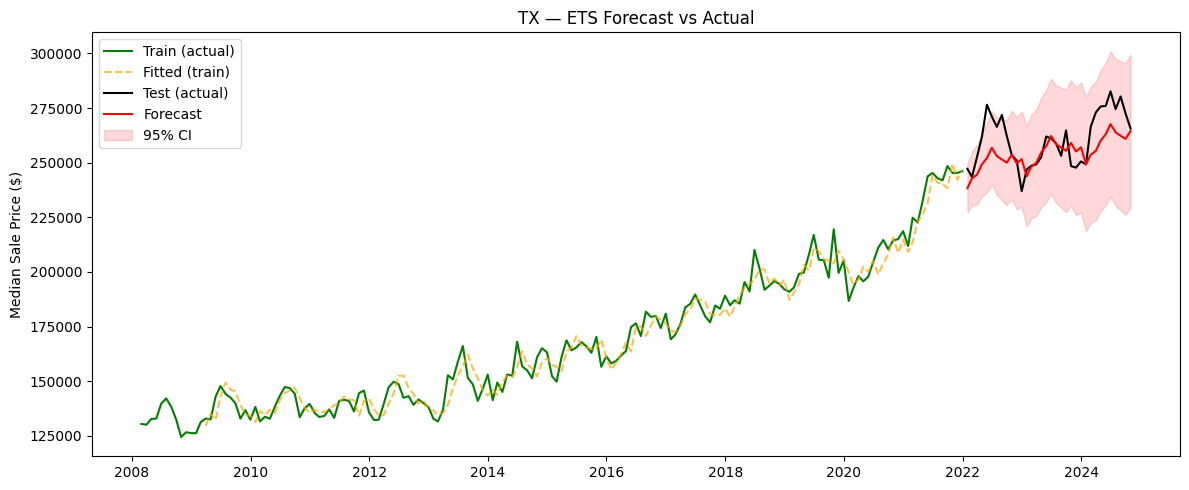

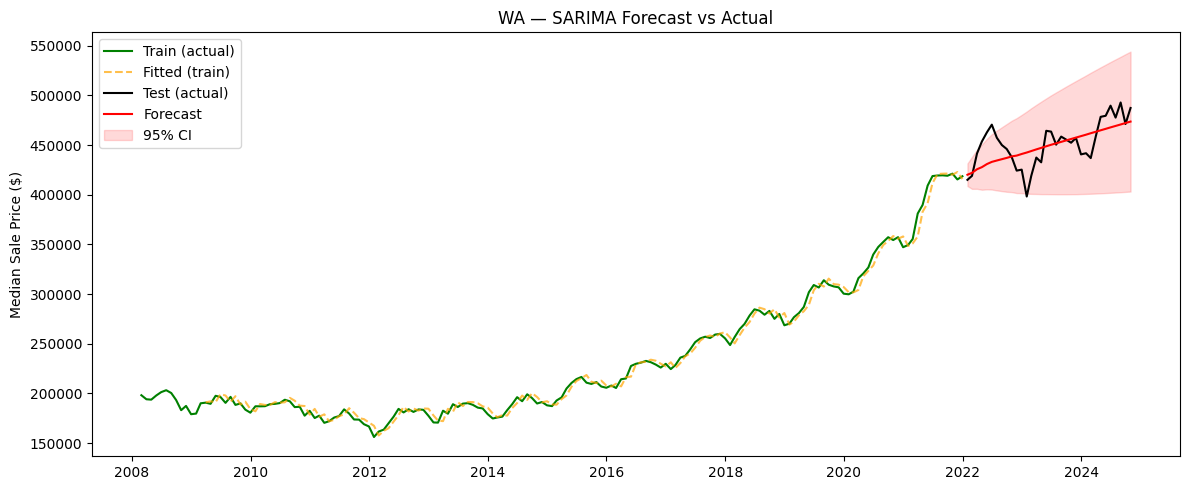

In [91]:
final_models = {
    'CA': ('sarima', sarima_fitted_models[('CA', 'manual')]),
    'NC': ('ets', ets_fitted_models[('NC', 'ETS(A,A,N) - no seasonal')]),
    'PA': ('ets', ets_fitted_models[('PA', 'ETS(A,A,N) - no seasonal')]),
    'TX': ('ets', ets_fitted_models[('TX', 'ETS(A,A,A) - seasonal')]),
    'WA': ('sarima', sarima_fitted_models[('WA', 'auto')]),
}

def get_forecast_and_ci(model_type, fit, h, train_index, test_index):
    """Returns (fitted_on_train, forecast, ci_lower, ci_upper) for any of the 3 model types."""
    if model_type == 'ets':
        fitted = fit.fittedvalues
        pred = fit.get_prediction(start=test_index[0], end=test_index[-1])
        summary = pred.summary_frame(alpha=0.05)
        forecast = summary['mean']
        ci_lower = summary['pi_lower']
        ci_upper = summary['pi_upper']
    else:  # sarima
        if isinstance(fit, pm.arima.ARIMA):
            fitted = pd.Series(fit.predict_in_sample(), index=train_index)
            forecast_vals, conf_int = fit.predict(h, return_conf_int=True)
            forecast = pd.Series(forecast_vals, index=test_index)
            ci_lower = pd.Series(conf_int[:, 0], index=test_index)
            ci_upper = pd.Series(conf_int[:, 1], index=test_index)
        else:
            fitted = fit.fittedvalues
            pred = fit.get_forecast(h)
            forecast = pred.predicted_mean
            ci = pred.conf_int(alpha=0.05)
            ci_lower = ci.iloc[:, 0]
            ci_upper = ci.iloc[:, 1]
    return fitted, forecast, ci_lower, ci_upper

for state, (model_type, fit) in final_models.items():
    train_series = states_train[state]
    test_series = states_test[state]
    h = len(test_series)

    fitted, forecast, ci_lower, ci_upper = get_forecast_and_ci(
        model_type, fit, h, train_series.index, test_series.index
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(train_series.index, train_series, color='green', label='Train (actual)')
    ax.plot(train_series.index[13:], fitted.iloc[13:], color='orange', linestyle='--', label='Fitted (train)', alpha=0.7)
    ax.plot(test_series.index, test_series, color='black', label='Test (actual)')
    ax.plot(test_series.index, forecast, color='red', label='Forecast')
    ax.fill_between(test_series.index, ci_lower, ci_upper, color='red', alpha=0.15, label='95% CI')

    ax.set_title(f'{state} — {model_type.upper()} Forecast vs Actual')
    ax.set_ylabel('Median Sale Price ($)')
    ax.legend()
    plt.tight_layout()
    plt.show()


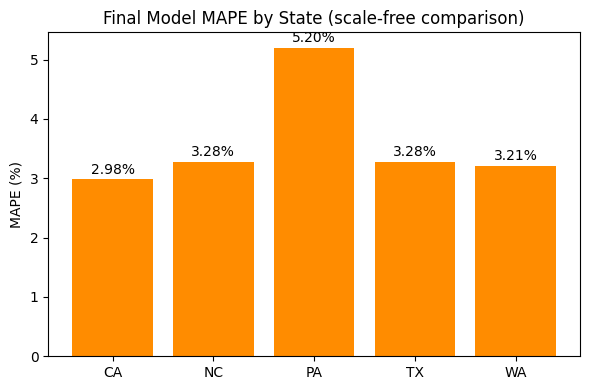

In [94]:
final_mape = final_df[final_df['Best in state?']].set_index('State')['MAPE (%)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(final_mape.index, final_mape.values, color='darkorange')
ax.set_ylabel('MAPE (%)')
ax.set_title('Final Model MAPE by State (scale-free comparison)')
for bar, val in zip(bars, final_mape.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}%', ha='center')
plt.tight_layout()
plt.show()